# Laboratorio 4 — Parte 1: análisis geoespacial de cianobacterias

**Universidad del Valle de Guatemala — CC3084 Data Science**

Lagos de **Atitlán** y **Amatitlán**, 11 fechas oficiales cada uno, **Sentinel-2 L1C**.

---

## Aviso sobre la versión anterior de este cuaderno

La primera versión de este cuaderno ejecutaba un **modo demostrativo sintético**
(`synthetic_bands()`) porque en ese momento no había rásteres descargados. Aquellos
resultados **no eran observaciones satelitales** y no deben citarse como hallazgos
ecológicos.

Este cuaderno se reescribió para trabajar **exclusivamente con los 22 GeoTIFF reales**
descargados de Copernicus Data Space. Correcciones aplicadas:

| Problema en la versión anterior | Corrección |
|---|---|
| Datos sintéticos presentados como reales | 22 escenas Sentinel-2 L1C reales; sin ningún *fallback* sintético |
| `normalize_band()` no escalaba los rásteres float32 con DN | Detección por magnitud; reflectancia = DN × 0.0001 aplicada **una sola vez** |
| `AREA_PIXEL_HA = 0.01` (asumía 10 m) | Área derivada de la transformación afín: **0.04 ha** (20 m) |
| Folium superponía un ráster UTM con límites geográficos | Reproyección real EPSG:32615 → EPSG:4326 antes de superponer |
| Índices sin verificar contra el evalscript | Comparación píxel a píxel con el evalscript literal de CyanoLakes |
| Fechas críticas escritas a mano | Calculadas con media + 1 desviación estándar por lago |

Todo el procesamiento pesado vive en `regenerar_parte1_real.py`. Este cuaderno lo
invoca y muestra los resultados **resumidos**, no millones de filas.


In [1]:
from pathlib import Path
import subprocess, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

# Rutas relativas: el cuaderno se ejecuta desde la raíz del repositorio.
ROOT = Path.cwd()
P1 = ROOT / "outputs" / "parte1_real"
TAB, FIG, MAP = P1 / "tables", P1 / "figures", P1 / "maps"

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

print("Directorio de trabajo:", ROOT)
print("Resultados reales en :", P1)
print("Python:", sys.version.split()[0])

Directorio de trabajo: C:\Users\mjyee\Downloads\DataScience\lab4data
Resultados reales en : C:\Users\mjyee\Downloads\DataScience\lab4data\outputs\parte1_real
Python: 3.11.9


## Actividades 1 y 2 — Conexión al API y adquisición de los rásteres

La conexión a Sentinel-2 se hizo con **openEO** contra Copernicus Data Space, mediante
autenticación OIDC (`descargar_rasters.py`). Esa descarga **ya se ejecutó**: este cuaderno
no vuelve a conectarse ni requiere credenciales.

Para cada lago y fecha oficial se descargaron las 9 bandas necesarias, recortadas al área
del lago, reproyectadas a **EPSG:32615** (UTM 15N) y remuestreadas a una resolución común
de **20 m**, que es la resolución nativa de las bandas *red-edge* y SWIR.


In [2]:
from mainlab4 import OFFICIAL_DATES, OFFICIAL_CLOUD_COVER, CYANO_REQUIRED_BANDS, S2_L1C_COLLECTION

manifiesto = pd.read_csv(ROOT / "outputs" / "manifests" / "raster_manifest.csv")

print("Colección:", S2_L1C_COLLECTION)
print("Bandas   :", ", ".join(CYANO_REQUIRED_BANDS))
print("Rásteres :", len(manifiesto))
display(manifiesto.groupby("lago").agg(
    n_fechas=("fecha", "count"), crs=("crs", "first"),
    resolucion_m=("res_x", "first"), dimensiones=("ancho", lambda s: f"{s.iloc[0]}x{manifiesto['alto'].iloc[0]}"),
    validos_pct_min=("validos_pct", "min")))

# Limitación documentada: la colección L1C de openEO no expone máscara de nubes.
print("\nMáscaras de nube disponibles en SENTINEL2_L1C: NINGUNA (no hay CLM/CLP/dataMask/SCL/QA60).")
print("Control de nubes disponible: selección oficial de escenas + filtros de validez espectral.")

Colección: SENTINEL2_L1C
Bandas   : B02, B03, B04, B05, B07, B08, B8A, B11, B12
Rásteres : 22


,n_fechas,crs,resolucion_m,dimensiones,validos_pct_min
lago,,,,,
Amatitlan,11,EPSG:32615,20.0,681x459,97.342
Atitlan,11,EPSG:32615,20.0,1380x459,98.016



Máscaras de nube disponibles en SENTINEL2_L1C: NINGUNA (no hay CLM/CLP/dataMask/SCL/QA60).
Control de nubes disponible: selección oficial de escenas + filtros de validez espectral.


## Actividad 3 — Índices y verificación del script de CyanoLakes

Se calculan sobre **reflectancia** (no sobre números digitales): NDVI, NDWI, MNDWI,
componentes del WBI, máscara de agua, FAI, NDCI y clorofila-a con el polinomio exacto del
evalscript *Cyanobacteria Chlorophyll-a NDCI L1C*.

La implementación vectorizada se contrasta **píxel a píxel** contra una traducción literal
del evalscript, para demostrar que reproduce el script oficial.


In [3]:
from regenerar_parte1_real import cargar_escena, verificar_evalscript, area_pixel_ha
from mainlab4 import reflectance_scale_report

escena = cargar_escena("Amatitlan", "2026-06-19", con_diagnostico=True)

print("=== Verificación de la escala radiométrica ===")
d = escena["diagnostico_escala"]["B08"]
print(f"Mediana de los DN originales : {d['mediana_original']:.1f}")
print(f"Factor aplicado             : {d['escala_aplicada']:.4g}  (una sola vez)")
print(f"Reflectancia resultante     : [{d['min_resultante']:.4f}, {d['max_resultante']:.4f}]")
assert 0 < d["mediana_resultante"] < 1.5, "La reflectancia quedó fuera de rango físico"

print("\n=== Área por píxel (derivada, no asumida) ===")
a = escena["area_pixel_ha"]
print(f"{abs(escena['transform'].a):.0f} m x {abs(escena['transform'].e):.0f} m = {a*10000:.0f} m2 = {a:.4f} ha")
assert abs(a - 0.04) < 1e-9, "El área por píxel debería ser 0.04 ha a 20 m"

print("\n=== Verificación contra el evalscript oficial ===")
ver = verificar_evalscript(escena, n_muestras=500)
print(f"Píxeles comparados uno a uno : {ver['pixeles_comparados']}")
print(f"Discrepancias en la máscara  : {ver['discrepancias_mascara_agua']}")
for k, v in ver["diferencias_maximas"].items():
    print(f"  diferencia máxima {k.upper():<5}: {v:.3e}")
print("Resultado:", "COINCIDE" if ver["coincide"] else "NO COINCIDE")
assert ver["coincide"], "La implementación local no reproduce el evalscript"

=== Verificación de la escala radiométrica ===
Mediana de los DN originales : 2764.0
Factor aplicado             : 0.0001  (una sola vez)
Reflectancia resultante     : [0.0103, 0.9055]

=== Área por píxel (derivada, no asumida) ===
20 m x 20 m = 400 m2 = 0.0400 ha

=== Verificación contra el evalscript oficial ===
Píxeles comparados uno a uno : 490
Discrepancias en la máscara  : 0
  diferencia máxima NDVI : 0.000e+00
  diferencia máxima NDWI : 0.000e+00
  diferencia máxima FAI  : 0.000e+00
  diferencia máxima NDCI : 0.000e+00
  diferencia máxima CHL  : 0.000e+00
Resultado: COINCIDE


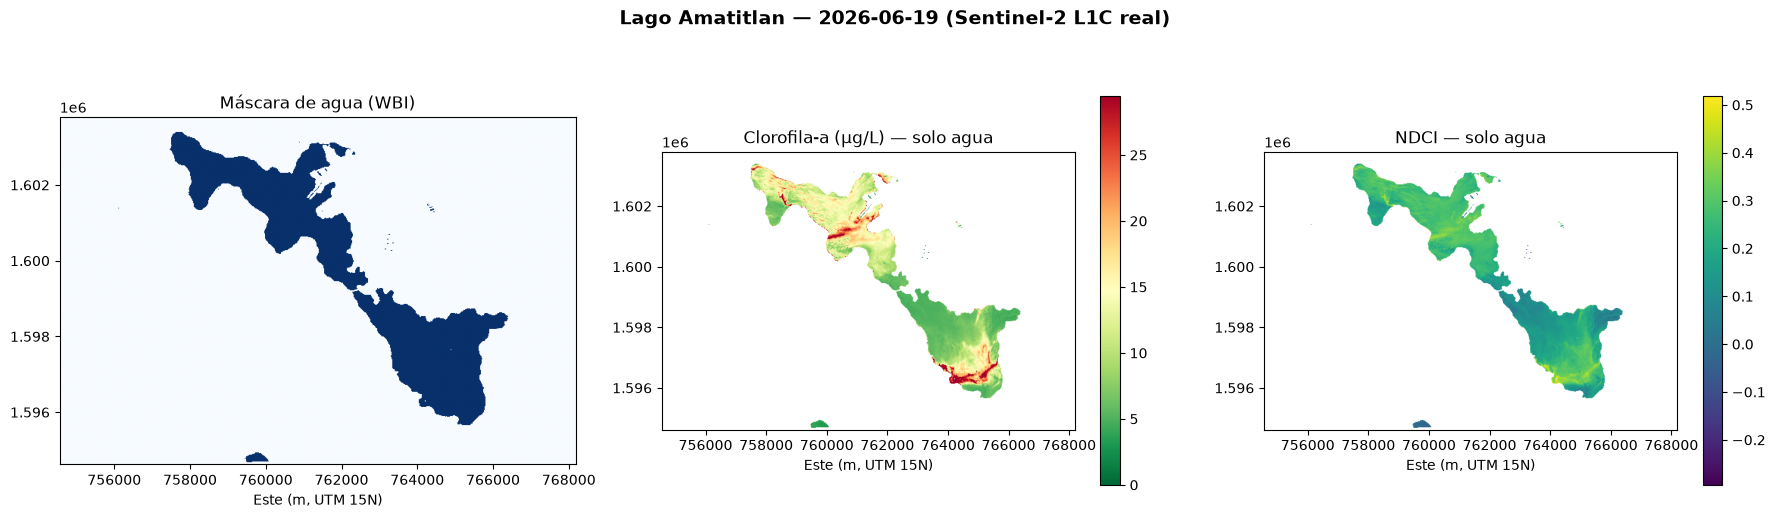

In [4]:
# Mapa del índice generado para una escena real (actividad 3: visualizar el índice)
b = escena["bounds"]
extent = [b.left, b.right, b.bottom, b.top]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
axes[0].imshow(escena["water"], cmap="Blues", extent=extent, origin="upper")
axes[0].set_title("Máscara de agua (WBI)")
im = axes[1].imshow(escena["chl_agua"], cmap="RdYlGn_r", extent=extent, origin="upper",
                    vmin=0, vmax=float(np.nanpercentile(escena["chl_agua"], 98)))
axes[1].set_title("Clorofila-a (µg/L) — solo agua")
plt.colorbar(im, ax=axes[1], shrink=0.8)
im2 = axes[2].imshow(np.where(escena["water"], escena["NDCI"], np.nan), cmap="viridis",
                     extent=extent, origin="upper")
axes[2].set_title("NDCI — solo agua")
plt.colorbar(im2, ax=axes[2], shrink=0.8)
for ax in axes:
    ax.set_xlabel("Este (m, UTM 15N)")
fig.suptitle(f"Lago {escena['lago']} — {escena['fecha']} (Sentinel-2 L1C real)",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

### Limitaciones del algoritmo de clorofila

Documentadas por la fuente del evalscript; **no** son estimaciones propias:

- Opera sobre **reflectancia de tope de atmósfera (L1C)**, sin corrección atmosférica.
- El polinomio fue **calibrado sobre datos simulados**, no sobre muestras de estos lagos.
- Calibración específica para ***Microcystis aeruginosa***; otras especies responden distinto.
- Errores reportados: **MAPE 42.3 %** y **RMSE relativo 95.8 %**.
- Dominio de calibración del NDCI: **1–60 mg/m³** (Mishra & Mishra, 2012).

Los valores son **estimaciones satelitales**, no mediciones de laboratorio. En este
laboratorio **no se realizó ninguna validación in situ**.


## Ejecución del pipeline real

Todo el cálculo pesado está en `regenerar_parte1_real.py`. Si los resultados ya existen se
reutilizan; para regenerarlos ejecute en una terminal:

```
python regenerar_parte1_real.py --dry-run
python regenerar_parte1_real.py --build
python regenerar_parte1_real.py --validate
```


In [5]:
if not (TAB / "serie_temporal_por_lago_fecha.csv").exists():
    print("No hay resultados; ejecutando el pipeline real (puede tardar unos minutos)...")
    r = subprocess.run([sys.executable, "regenerar_parte1_real.py", "--build"],
                       cwd=ROOT, capture_output=True, text=True)
    print(r.stdout[-2000:])
    if r.returncode != 0:
        raise RuntimeError("El pipeline real falló. NO se sustituye por datos sintéticos.")
else:
    print("Resultados reales ya disponibles en", TAB)

serie = pd.read_csv(TAB / "serie_temporal_por_lago_fecha.csv")
print(f"Serie temporal: {len(serie)} filas ({serie['lago'].nunique()} lagos x 11 fechas)")

Resultados reales ya disponibles en C:\Users\mjyee\Downloads\DataScience\lab4data\outputs\parte1_real\tables
Serie temporal: 22 filas (2 lagos x 11 fechas)


## Actividad 4 — Análisis temporal

Índice promedio de cianobacteria (clorofila-a) por lago y fecha, con mediana, desviación
estándar y percentiles calculados sobre los píxeles de agua reales.


In [6]:
cols = ["lago", "fecha", "area_agua_ha", "chl_media", "chl_mediana", "chl_std",
        "chl_p95", "chl_max", "nubosidad_oficial_pct"]
display(serie[cols].round(3))

print("\nResumen por lago (µg/L):")
display(serie.groupby("lago")[["chl_media", "chl_mediana", "chl_std", "chl_max"]].agg(["mean", "min", "max"]).round(3))

,lago,fecha,area_agua_ha,chl_media,chl_mediana,chl_std,chl_p95,chl_max,nubosidad_oficial_pct
0,Amatitlan,2025-01-28,1462.00,4.419,4.483,0.833,4.816,23.556,0.06
1,Amatitlan,2025-04-15,1447.40,4.539,4.581,1.350,6.535,26.284,0.09
2,Amatitlan,2025-04-28,1447.36,5.767,4.877,2.965,11.514,42.443,1.03
3,Amatitlan,2025-11-24,1457.36,4.643,4.008,5.494,6.234,113.828,0.50
4,Amatitlan,2026-01-08,1466.72,6.655,4.889,8.558,13.234,130.118,0.77
5,Amatitlan,2026-02-02,1445.20,4.280,4.392,0.646,4.776,16.494,0.39
6,Amatitlan,2026-02-07,1462.44,4.302,4.447,0.823,4.799,17.756,0.02
7,Amatitlan,2026-03-29,1463.76,6.445,5.246,3.961,15.375,51.997,0.01
8,Amatitlan,2026-04-13,1471.44,6.771,6.403,1.747,9.954,36.592,0.09
9,Amatitlan,2026-04-28,1396.44,9.923,6.445,7.496,26.102,47.145,4.96



Resumen por lago (µg/L):


chl_media                chl_mediana                chl_std               chl_max                 
               mean    min     max        mean    min     max    mean    min    max    mean     min      max
lago                                                                                                        
Amatitlan     6.295  4.280  11.503       5.494  4.008  10.662   3.675  0.646  8.558  53.413  16.494  130.118
Atitlan       1.114  0.218   2.097       1.126  0.232   2.182   1.187  0.813  1.868  32.921  14.733  135.861

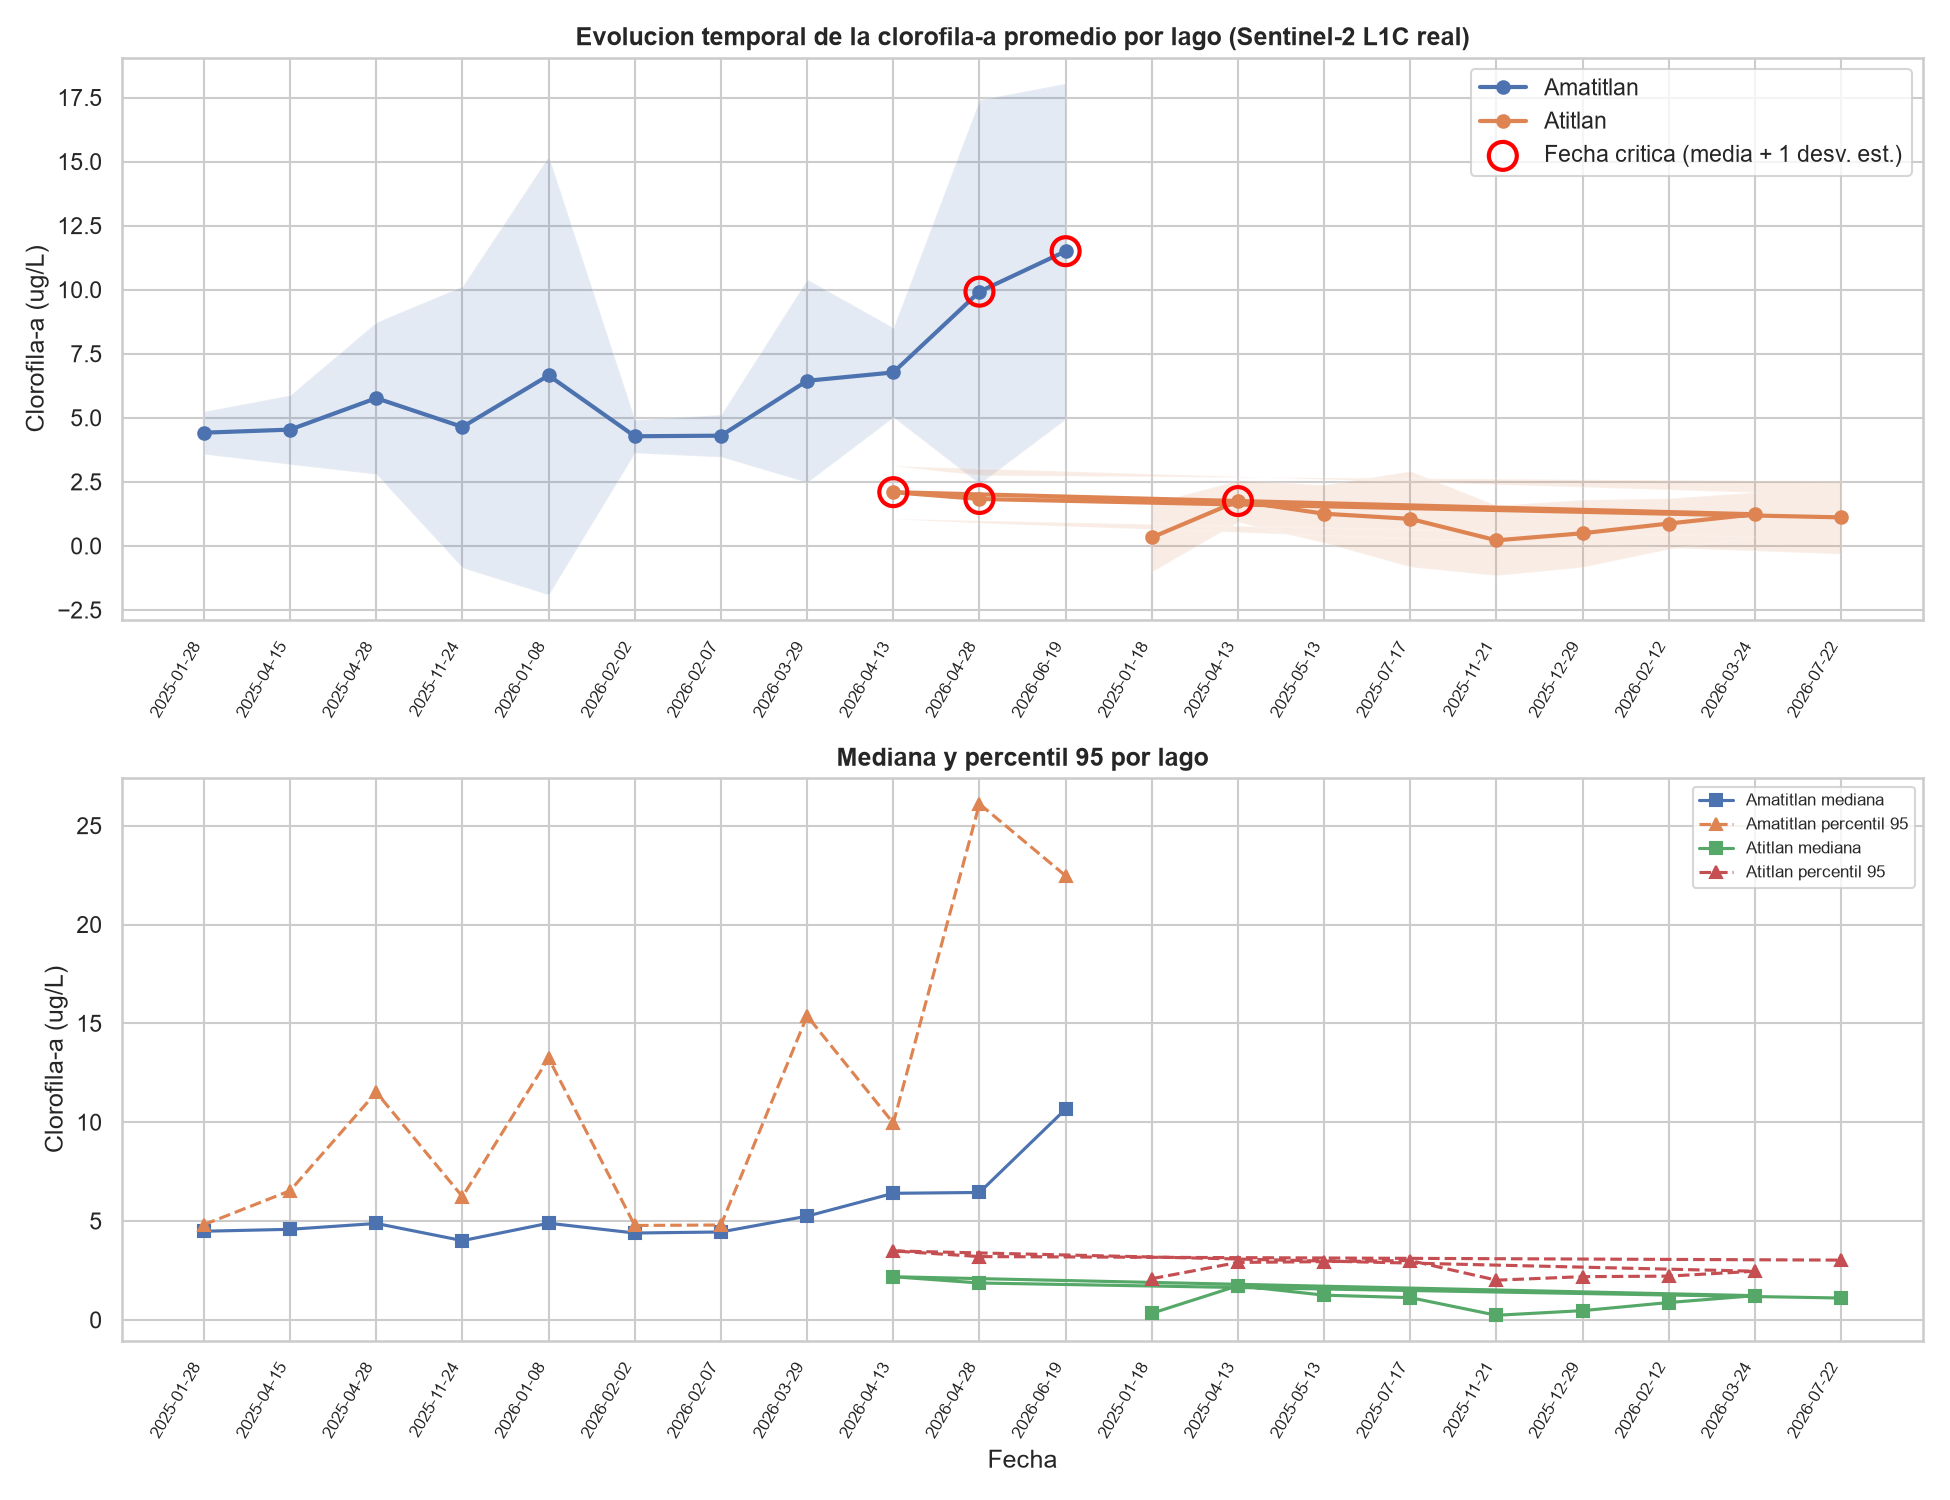

Fechas críticas (calculadas: media + 1 desviación estándar por lago):


,lago,fecha,chl_media,umbral_pico,criterio
0,Amatitlan,2026-04-28,9.923,8.71,media + 1 desviacion estandar del lago
1,Amatitlan,2026-06-19,11.503,8.71,media + 1 desviacion estandar del lago
2,Atitlan,2025-04-13,1.751,1.73,media + 1 desviacion estandar del lago
3,Atitlan,2026-04-13,2.097,1.73,media + 1 desviacion estandar del lago
4,Atitlan,2026-04-28,1.832,1.73,media + 1 desviacion estandar del lago


In [7]:
display(Image(filename=str(FIG / "actividad4_evolucion_temporal.png")))

print("Fechas críticas (calculadas: media + 1 desviación estándar por lago):")
display(pd.read_csv(TAB / "fechas_criticas.csv").round(3))

### Interpretación temporal (basada en las cifras de arriba)

- **Amatitlán** presenta concentraciones de un orden de magnitud superiores a las de
  Atitlán en todas las fechas, y una **tendencia creciente** hacia el final del período,
  con los valores más altos entre abril y junio de 2026.
- **Atitlán** se mantiene en valores bajos (medias por debajo de ~2 µg/L), compatibles con
  un lago oligotrófico–mesotrófico. Sus máximos ocurren también en abril.
- En ambos lagos los mínimos aparecen en **noviembre–diciembre**, al final de la temporada
  lluviosa.

La coincidencia con la estación seca–lluviosa es **una asociación temporal, no una
relación causal demostrada**: para atribuir causas harían falta datos de nutrientes,
temperatura del agua y caudales que este laboratorio no incorpora.


## Actividad 5 — Análisis espacial

Mapas de clorofila-a por fecha con **escala común**, comparación entre la fecha de menor y
mayor concentración, mapa de diferencia y mapa interactivo con reproyección real a
EPSG:4326.


#### Lago Amatitlan: las 11 fechas oficiales (escala común)

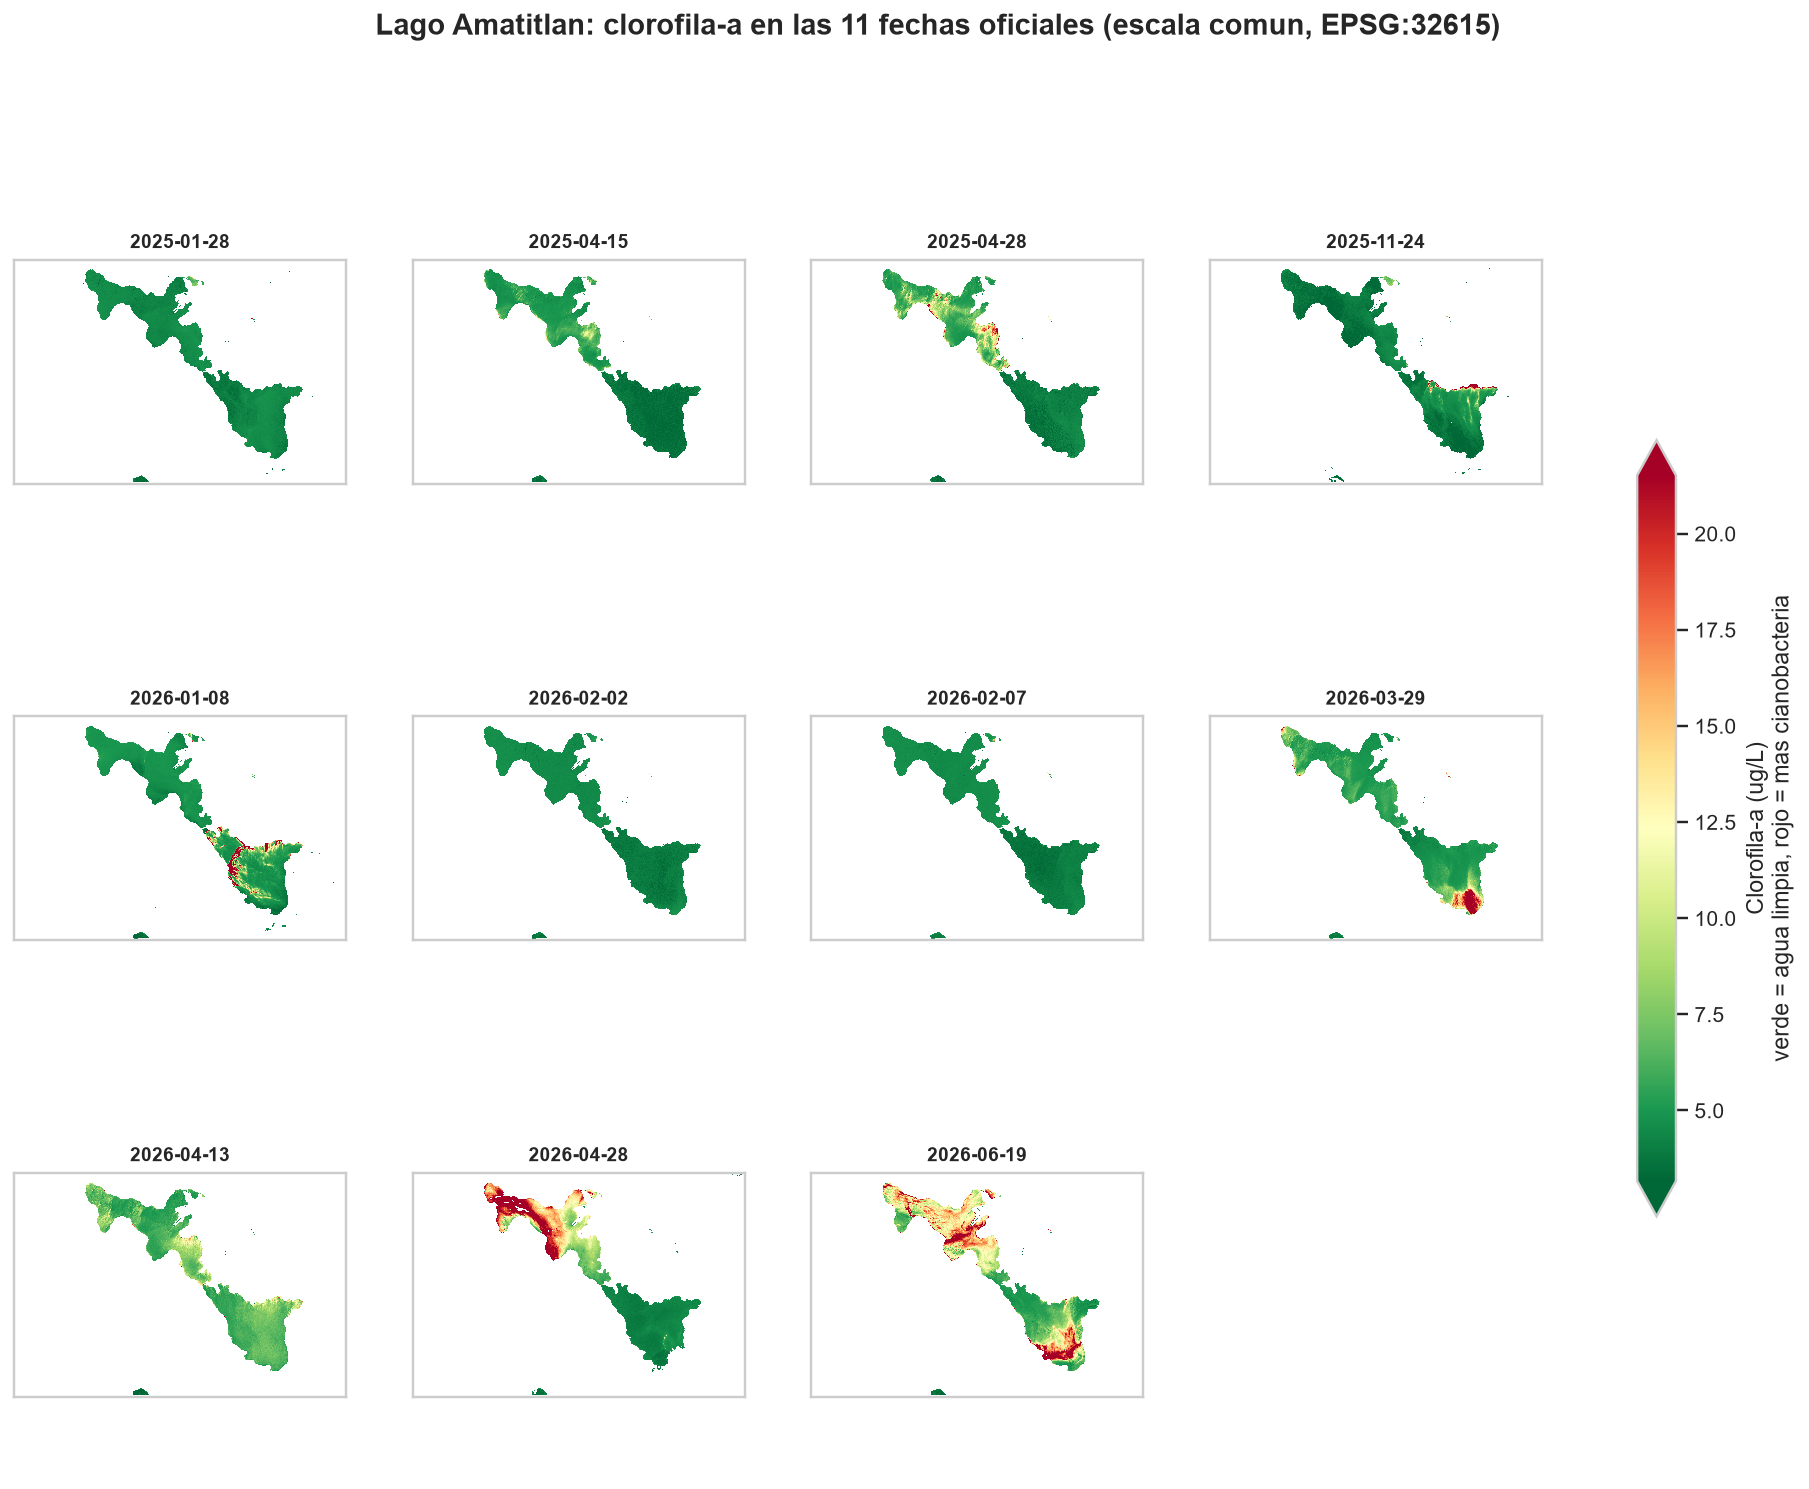

#### Lago Atitlan: las 11 fechas oficiales (escala común)

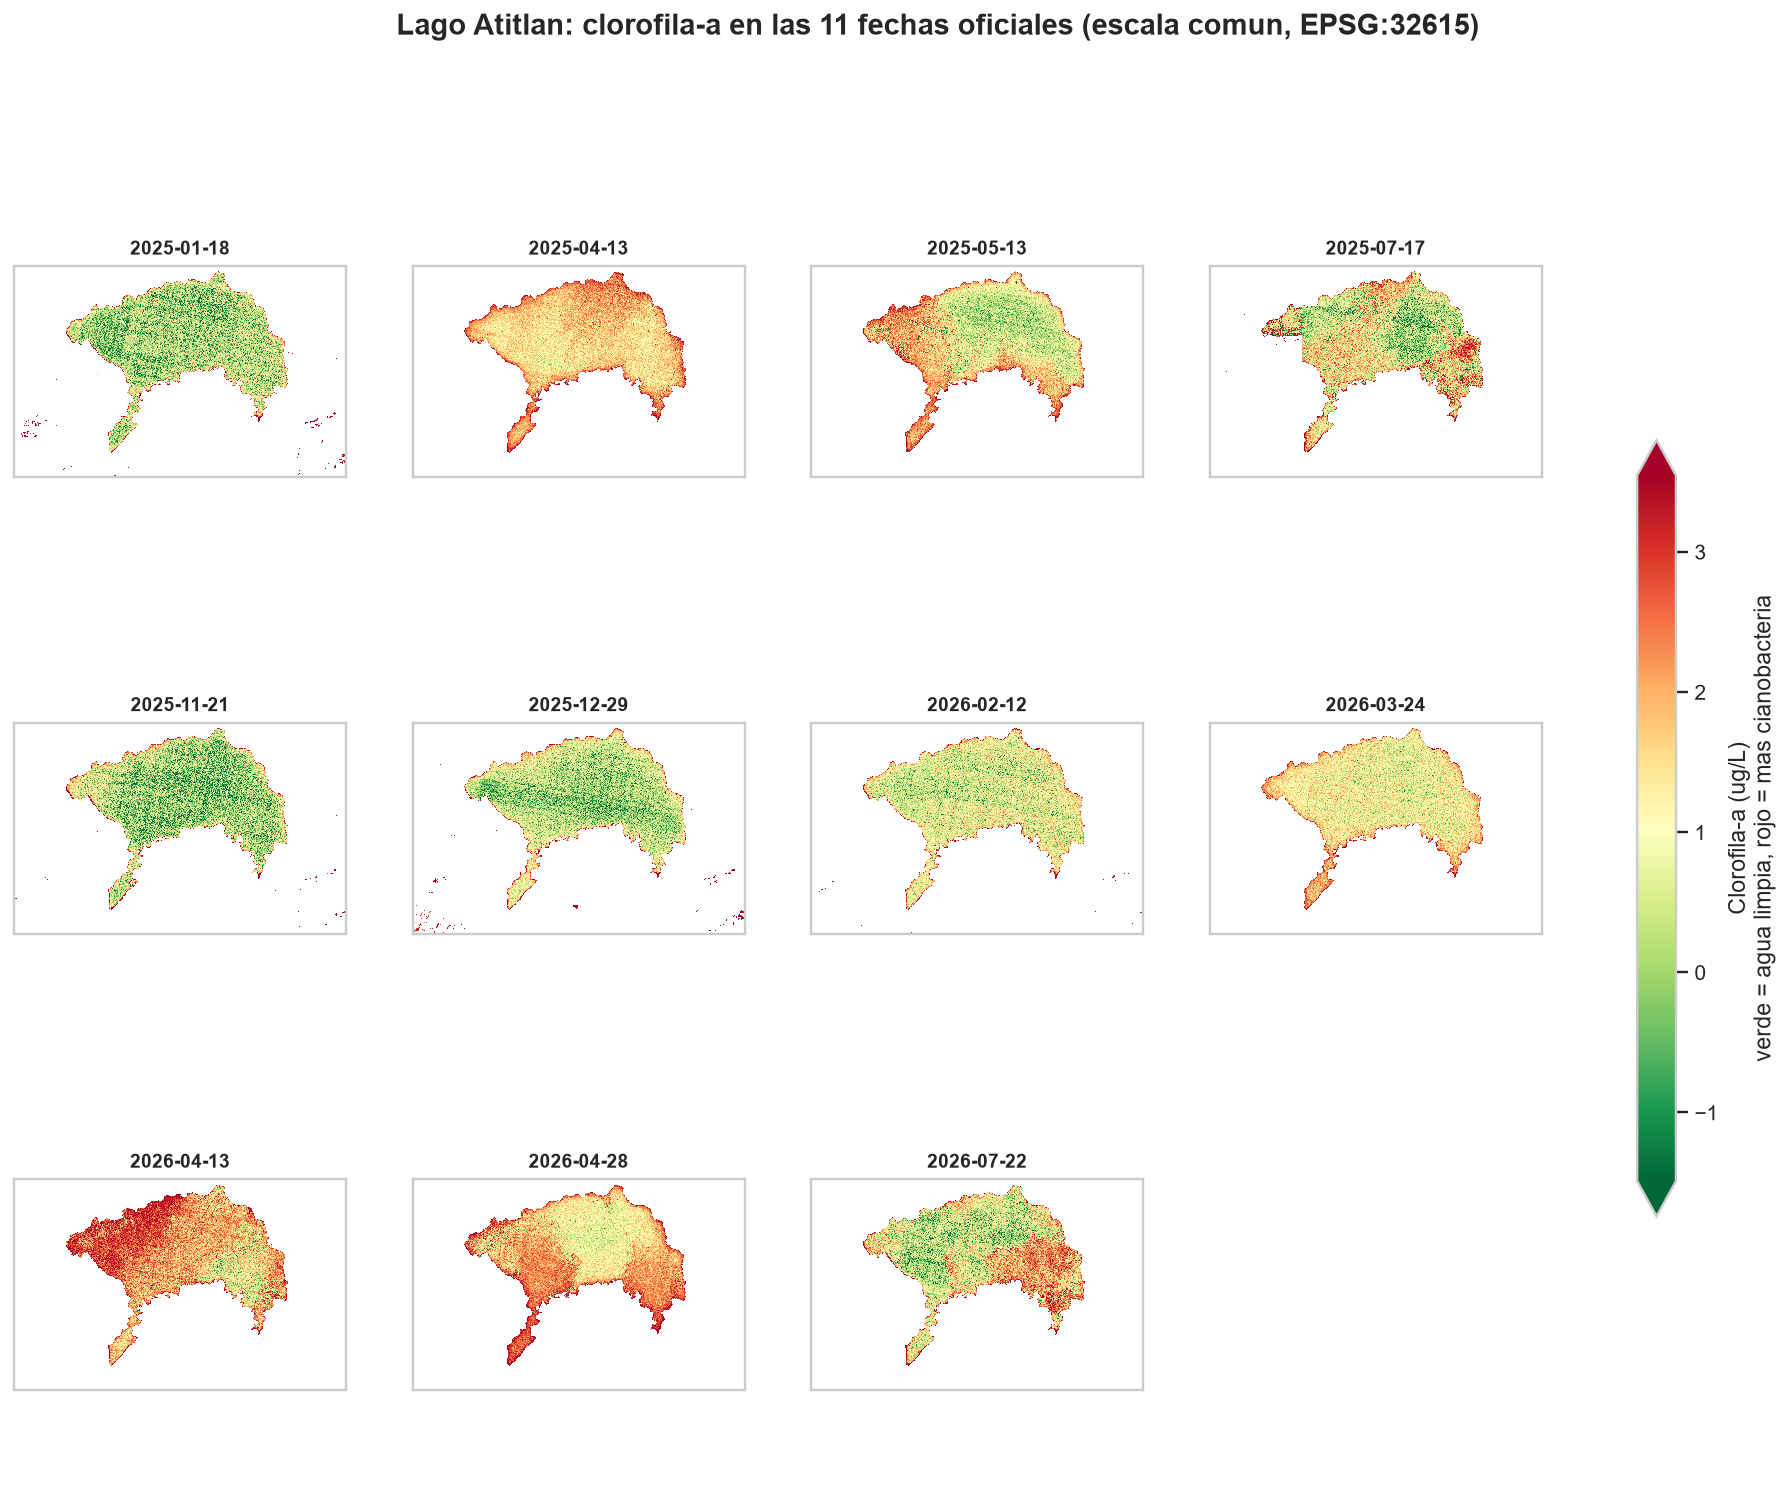

In [8]:
for lago in sorted(OFFICIAL_DATES):
    display(Markdown(f"#### Lago {lago}: las 11 fechas oficiales (escala común)"))
    display(Image(filename=str(MAP / f"actividad5_mapas_por_fecha_{lago}.png")))

#### Lago Amatitlan: mínimo vs máximo y mapa de diferencia

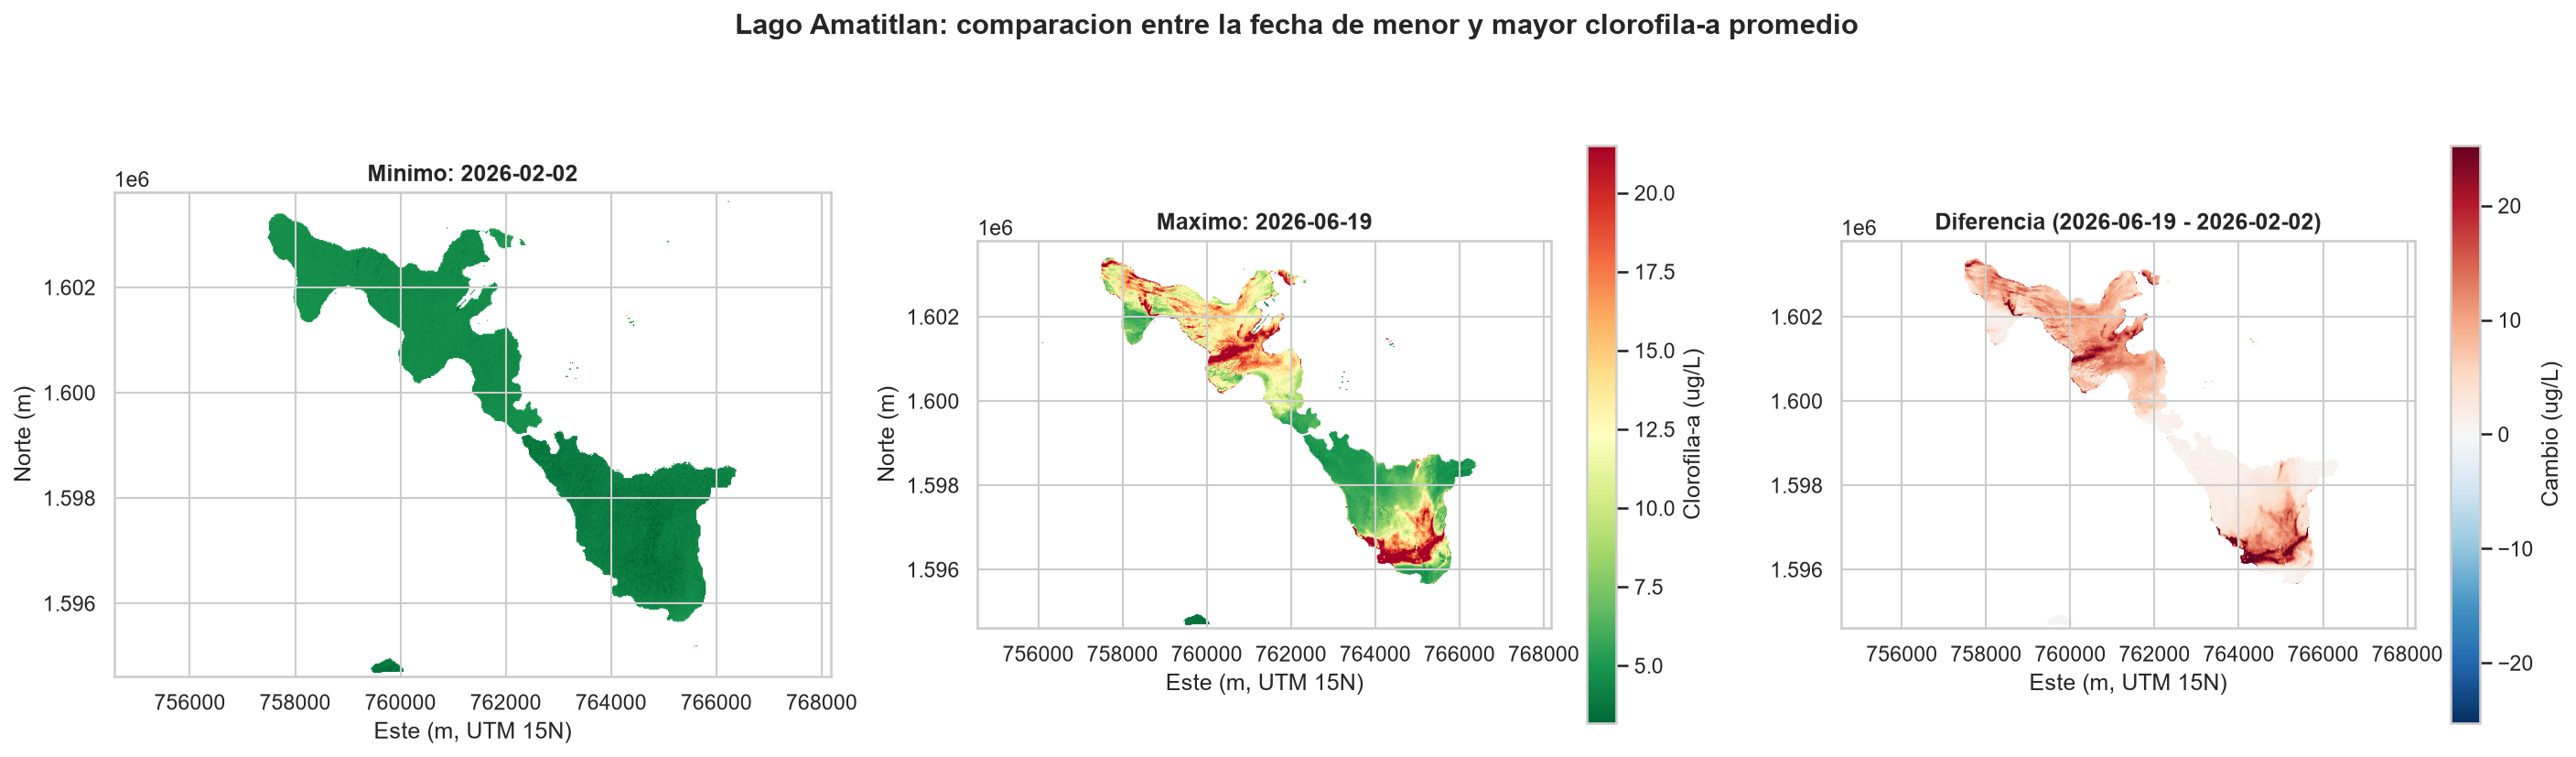

#### Lago Atitlan: mínimo vs máximo y mapa de diferencia

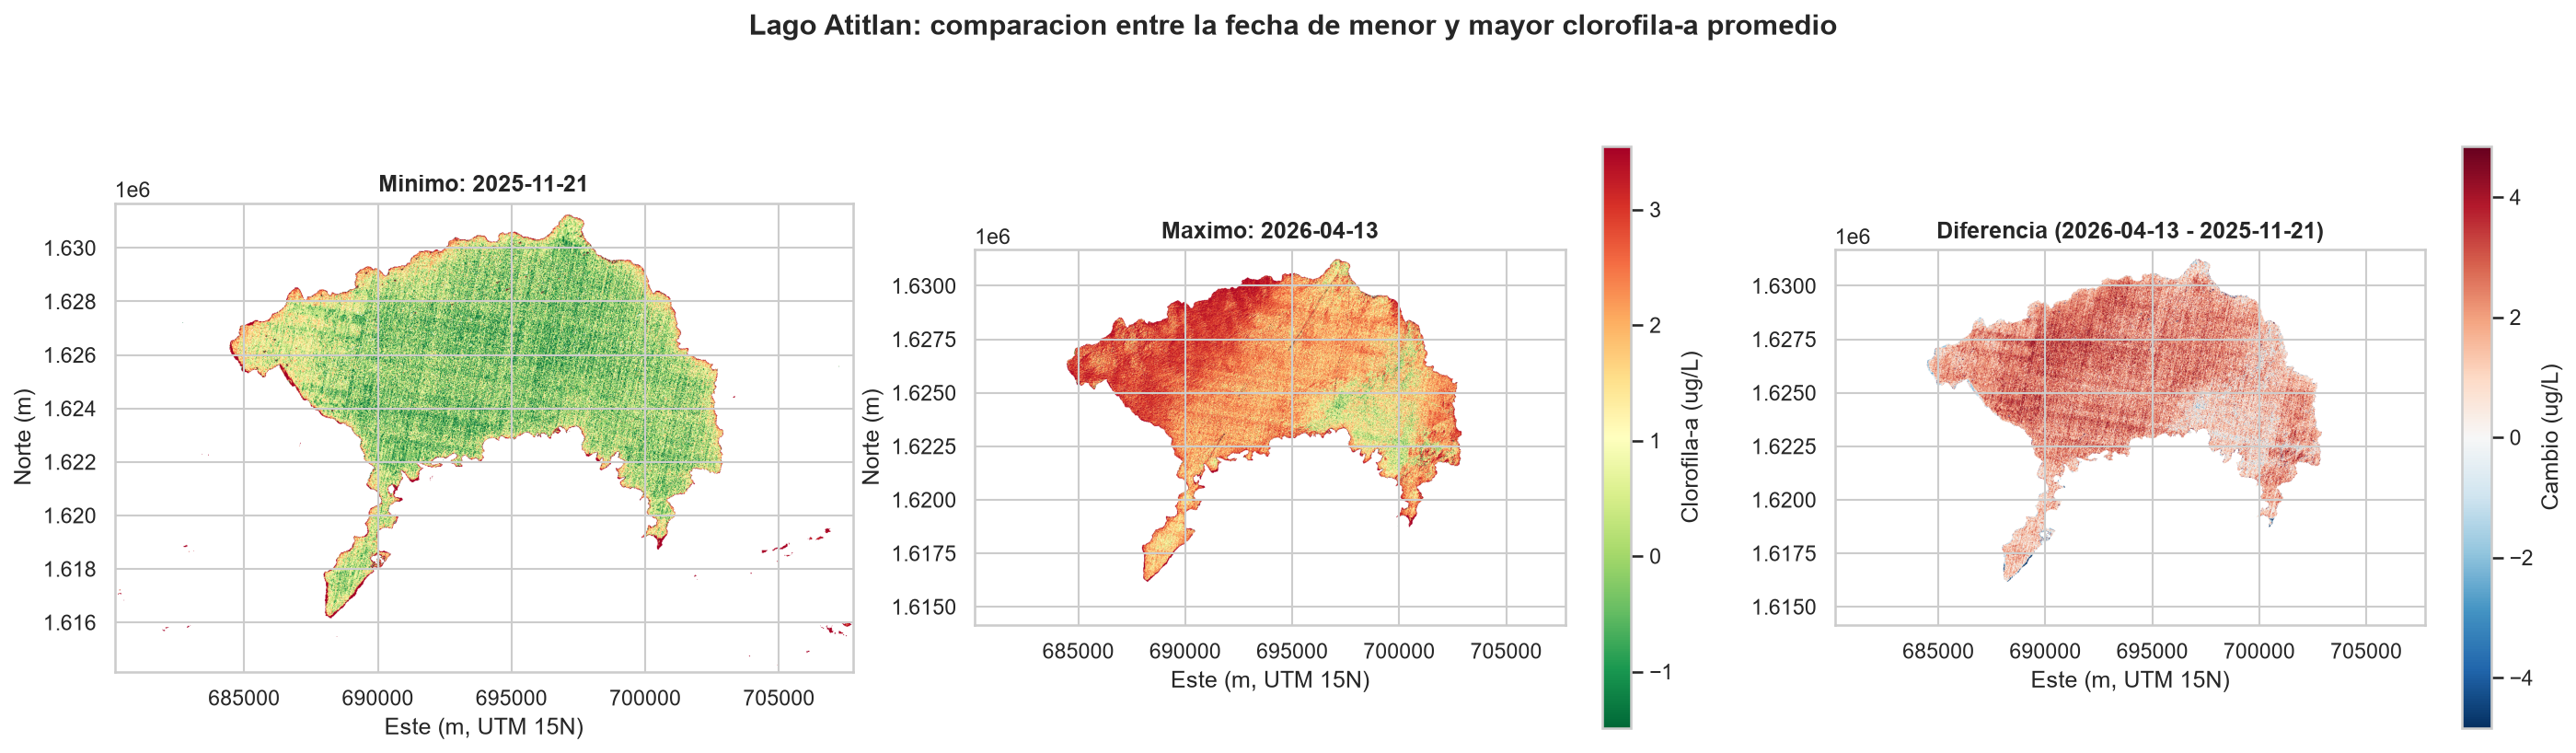

Mapas interactivos generados (ábralos en el navegador):
   outputs\parte1_real\maps\actividad5_mapa_interactivo_Amatitlan.html
   outputs\parte1_real\maps\actividad5_mapa_interactivo_Atitlan.html


In [9]:
for lago in sorted(OFFICIAL_DATES):
    display(Markdown(f"#### Lago {lago}: mínimo vs máximo y mapa de diferencia"))
    display(Image(filename=str(MAP / f"actividad5_comparativo_min_max_{lago}.png")))

print("Mapas interactivos generados (ábralos en el navegador):")
for h in sorted(MAP.glob("*.html")):
    print("  ", h.relative_to(ROOT))

### Interpretación espacial

Los valores altos **no se distribuyen de forma homogénea**: se concentran en zonas
litorales y de menor profundidad, especialmente cerca de desembocaduras, mientras que las
aguas abiertas y profundas mantienen valores bajos. El mapa de diferencia entre la fecha
mínima y la máxima muestra que el cambio también es espacialmente selectivo: crece sobre
todo en las mismas zonas someras.

Las zonas de acumulación persistente se cuantifican en la actividad 8.


## Actividad 6 — Correlación entre índices

Correlación de Pearson calculada **solo sobre píxeles de agua válidos**, agregando las 11
fechas de cada lago.


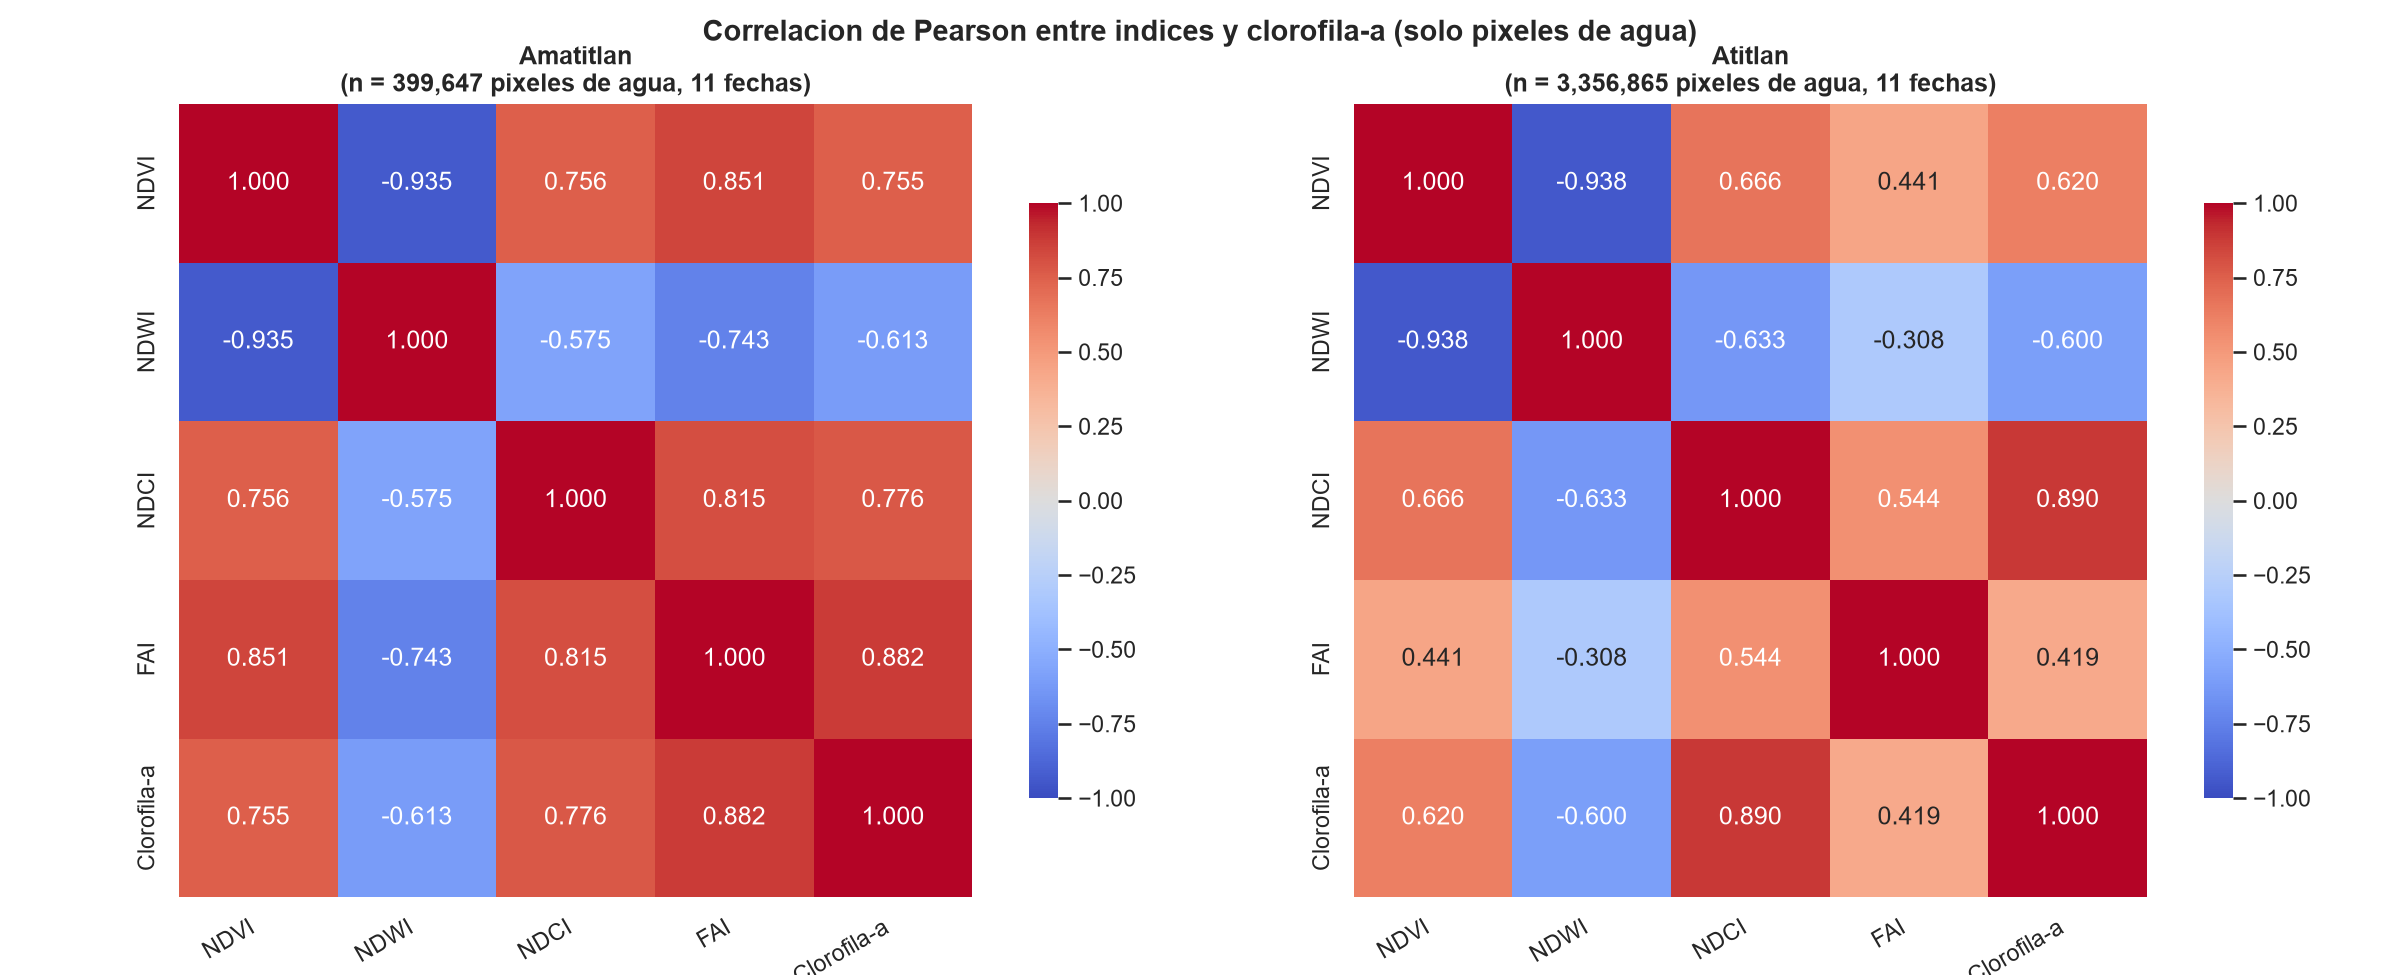

lago               Amatitlan  Atitlan
var_a       var_b                    
Clorofila-a FAI        0.882    0.419
            NDCI       0.776    0.890
            NDVI       0.755    0.620
            NDWI      -0.613   -0.600
FAI         NDCI       0.815    0.544
            NDVI       0.851    0.441
            NDWI      -0.743   -0.308
NDCI        NDVI       0.756    0.666
            NDWI      -0.575   -0.633
NDVI        NDWI      -0.935   -0.938

In [10]:
display(Image(filename=str(FIG / "actividad6_correlaciones.png")))
corr = pd.read_csv(TAB / "correlaciones_agregadas.csv")
display(corr.pivot(index=["var_a", "var_b"], columns="lago", values="pearson").round(3))

### Hallazgos y advertencia de circularidad

- **NDWI ↔ clorofila-a: negativa** en ambos lagos. Es la relación **ambientalmente
  interpretable**: el NDWI no participa en el cálculo de la clorofila, así que la
  asociación es informativa. Un agua con más biomasa algal reduce el contraste
  verde–infrarrojo característico del agua limpia.
- **NDVI ↔ clorofila-a: positiva**. Coherente con que las acumulaciones densas de algas se
  comportan espectralmente como vegetación, pero el NDVI comparte la banda **B04** con el
  NDCI, así que hay dependencia parcial.
- **NDCI ↔ clorofila-a: alta y positiva.** ⚠️ **Esto no es evidencia ecológica.** La
  clorofila se calcula como un polinomio del NDCI: la relación es una **identidad
  matemática** y su valor alto era inevitable. Reportarla como un hallazgo sería
  circular.
- **FAI ↔ clorofila-a**: también comparte B04 con el NDCI; misma advertencia atenuada.

La correlación fuertemente negativa entre NDVI y NDWI (≈ −0.93) es la esperada por
construcción y funciona como control de calidad del procesamiento.


## Actividad 7 — Comparación entre lagos

,0,1
lago,Amatitlan,Atitlan
chl_media_periodo,6.295,1.114
chl_mediana_periodo,4.877,1.124
chl_max_observada,130.118,135.861
variabilidad_entre_fechas_std,2.415,0.615
coef_variacion,0.384,0.552
area_agua_media_ha,1453.262,12206.782
area_agua_media_km2,14.533,122.068
fechas_con_area_sobre_25,8,6
pct_area_max_sobre_25,6.101,0.002


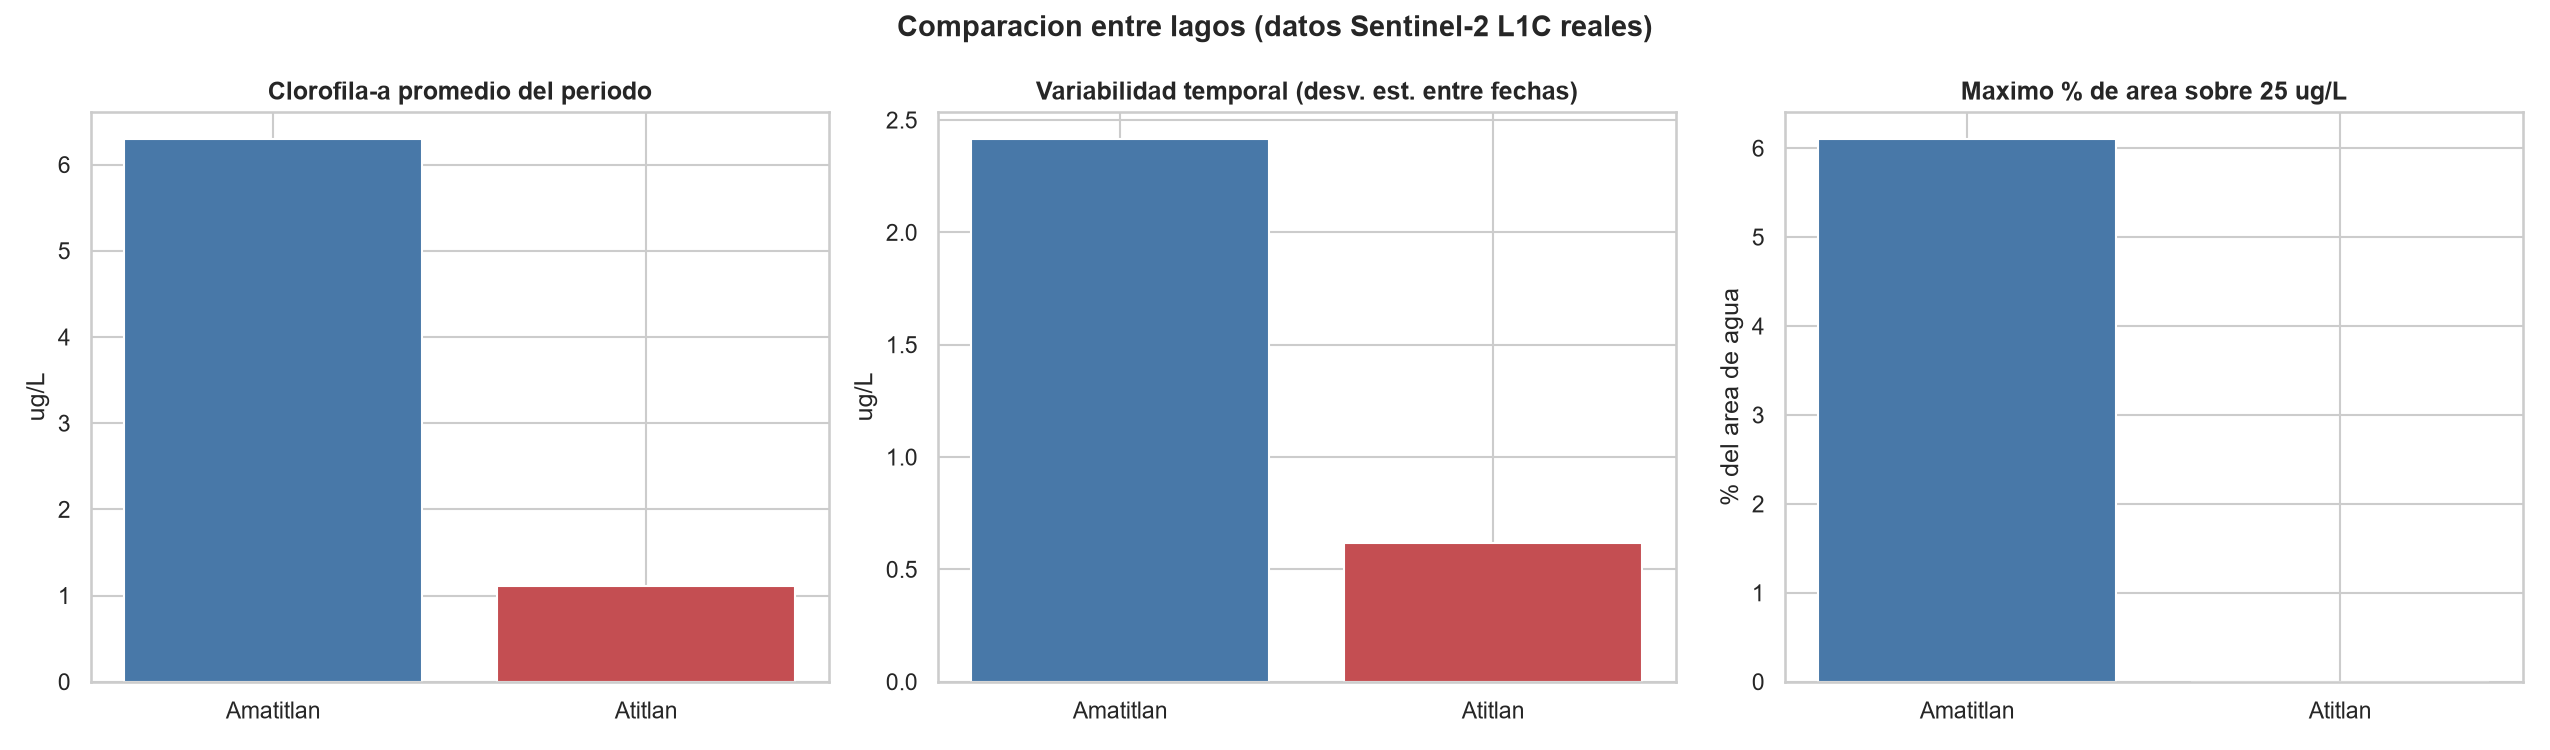

In [11]:
comp = pd.read_csv(TAB / "comparacion_entre_lagos.csv")
display(comp.round(3).T)
display(Image(filename=str(FIG / "actividad7_comparacion_lagos.png")))

### Diferencias observadas y factores plausibles

**Intensidad.** Amatitlán presenta una clorofila-a promedio del período muy superior a la
de Atitlán, y sus máximos por fecha son varias veces mayores.

**Frecuencia y extensión.** Amatitlán supera los umbrales ambientales en muchas más fechas
y sobre una fracción mucho mayor de su superficie (ver actividad 8).

**Variabilidad.** Amatitlán muestra mayor desviación estándar entre fechas: su estado
cambia más a lo largo del año.

**Factores que podrían explicarlo** (hipótesis coherentes con la literatura, *no*
demostradas por estos datos):

- **Profundidad y volumen.** Atitlán es un lago volcánico profundo (>300 m); Amatitlán es
  somero. Un volumen mayor diluye nutrientes y estratifica distinto.
- **Presión urbana.** Amatitlán recibe la descarga de la cuenca del área metropolitana de
  Guatemala a través del río Villalobos; Atitlán no tiene una presión urbana equivalente.
- **Superficie.** Atitlán ≈ 122 km² detectados frente a ≈ 14,5 km² de Amatitlán.

**Contexto climático.** Las referencias de WeatherSpark del enunciado aportan
**promedios climatológicos** (temperatura y precipitación típicas por mes), no las
condiciones meteorológicas del día de cada escena. Sirven para describir la estacionalidad
general de la región, pero **no permiten atribuir causalidad** a ninguna fecha concreta.


## Actividad 8 — Análisis exploratorio adicional

Extensión espacial por umbral, distribuciones, persistencia y patrón estacional.


In [12]:
ext = pd.read_csv(TAB / "extension_espacial_por_umbral.csv")
UMBRAL = 25.0
sub = ext[ext["umbral_ug_L"] == UMBRAL]
print(f"Extensión espacial con umbral {UMBRAL:.0f} µg/L (área de píxel = 0.04 ha):")
display(sub[["lago", "fecha", "pixeles_positivos", "pct_area_afectada",
             "area_afectada_ha", "area_agua_total_ha"]].round(3))

Extensión espacial con umbral 25 µg/L (área de píxel = 0.04 ha):


,lago,fecha,pixeles_positivos,pct_area_afectada,area_afectada_ha,area_agua_total_ha
2,Amatitlan,2025-01-28,0,0.000,0.00,1462.00
6,Amatitlan,2025-04-15,1,0.003,0.04,1447.40
10,Amatitlan,2025-04-28,64,0.177,2.56,1447.36
14,Amatitlan,2025-11-24,303,0.832,12.12,1457.36
18,Amatitlan,2026-01-08,917,2.501,36.68,1466.72
22,Amatitlan,2026-02-02,0,0.000,0.00,1445.20
26,Amatitlan,2026-02-07,0,0.000,0.00,1462.44
30,Amatitlan,2026-03-29,461,1.260,18.44,1463.76
34,Amatitlan,2026-04-13,12,0.033,0.48,1471.44
38,Amatitlan,2026-04-28,2130,6.101,85.20,1396.44


#### Lago Amatitlan: distribuciones por fecha

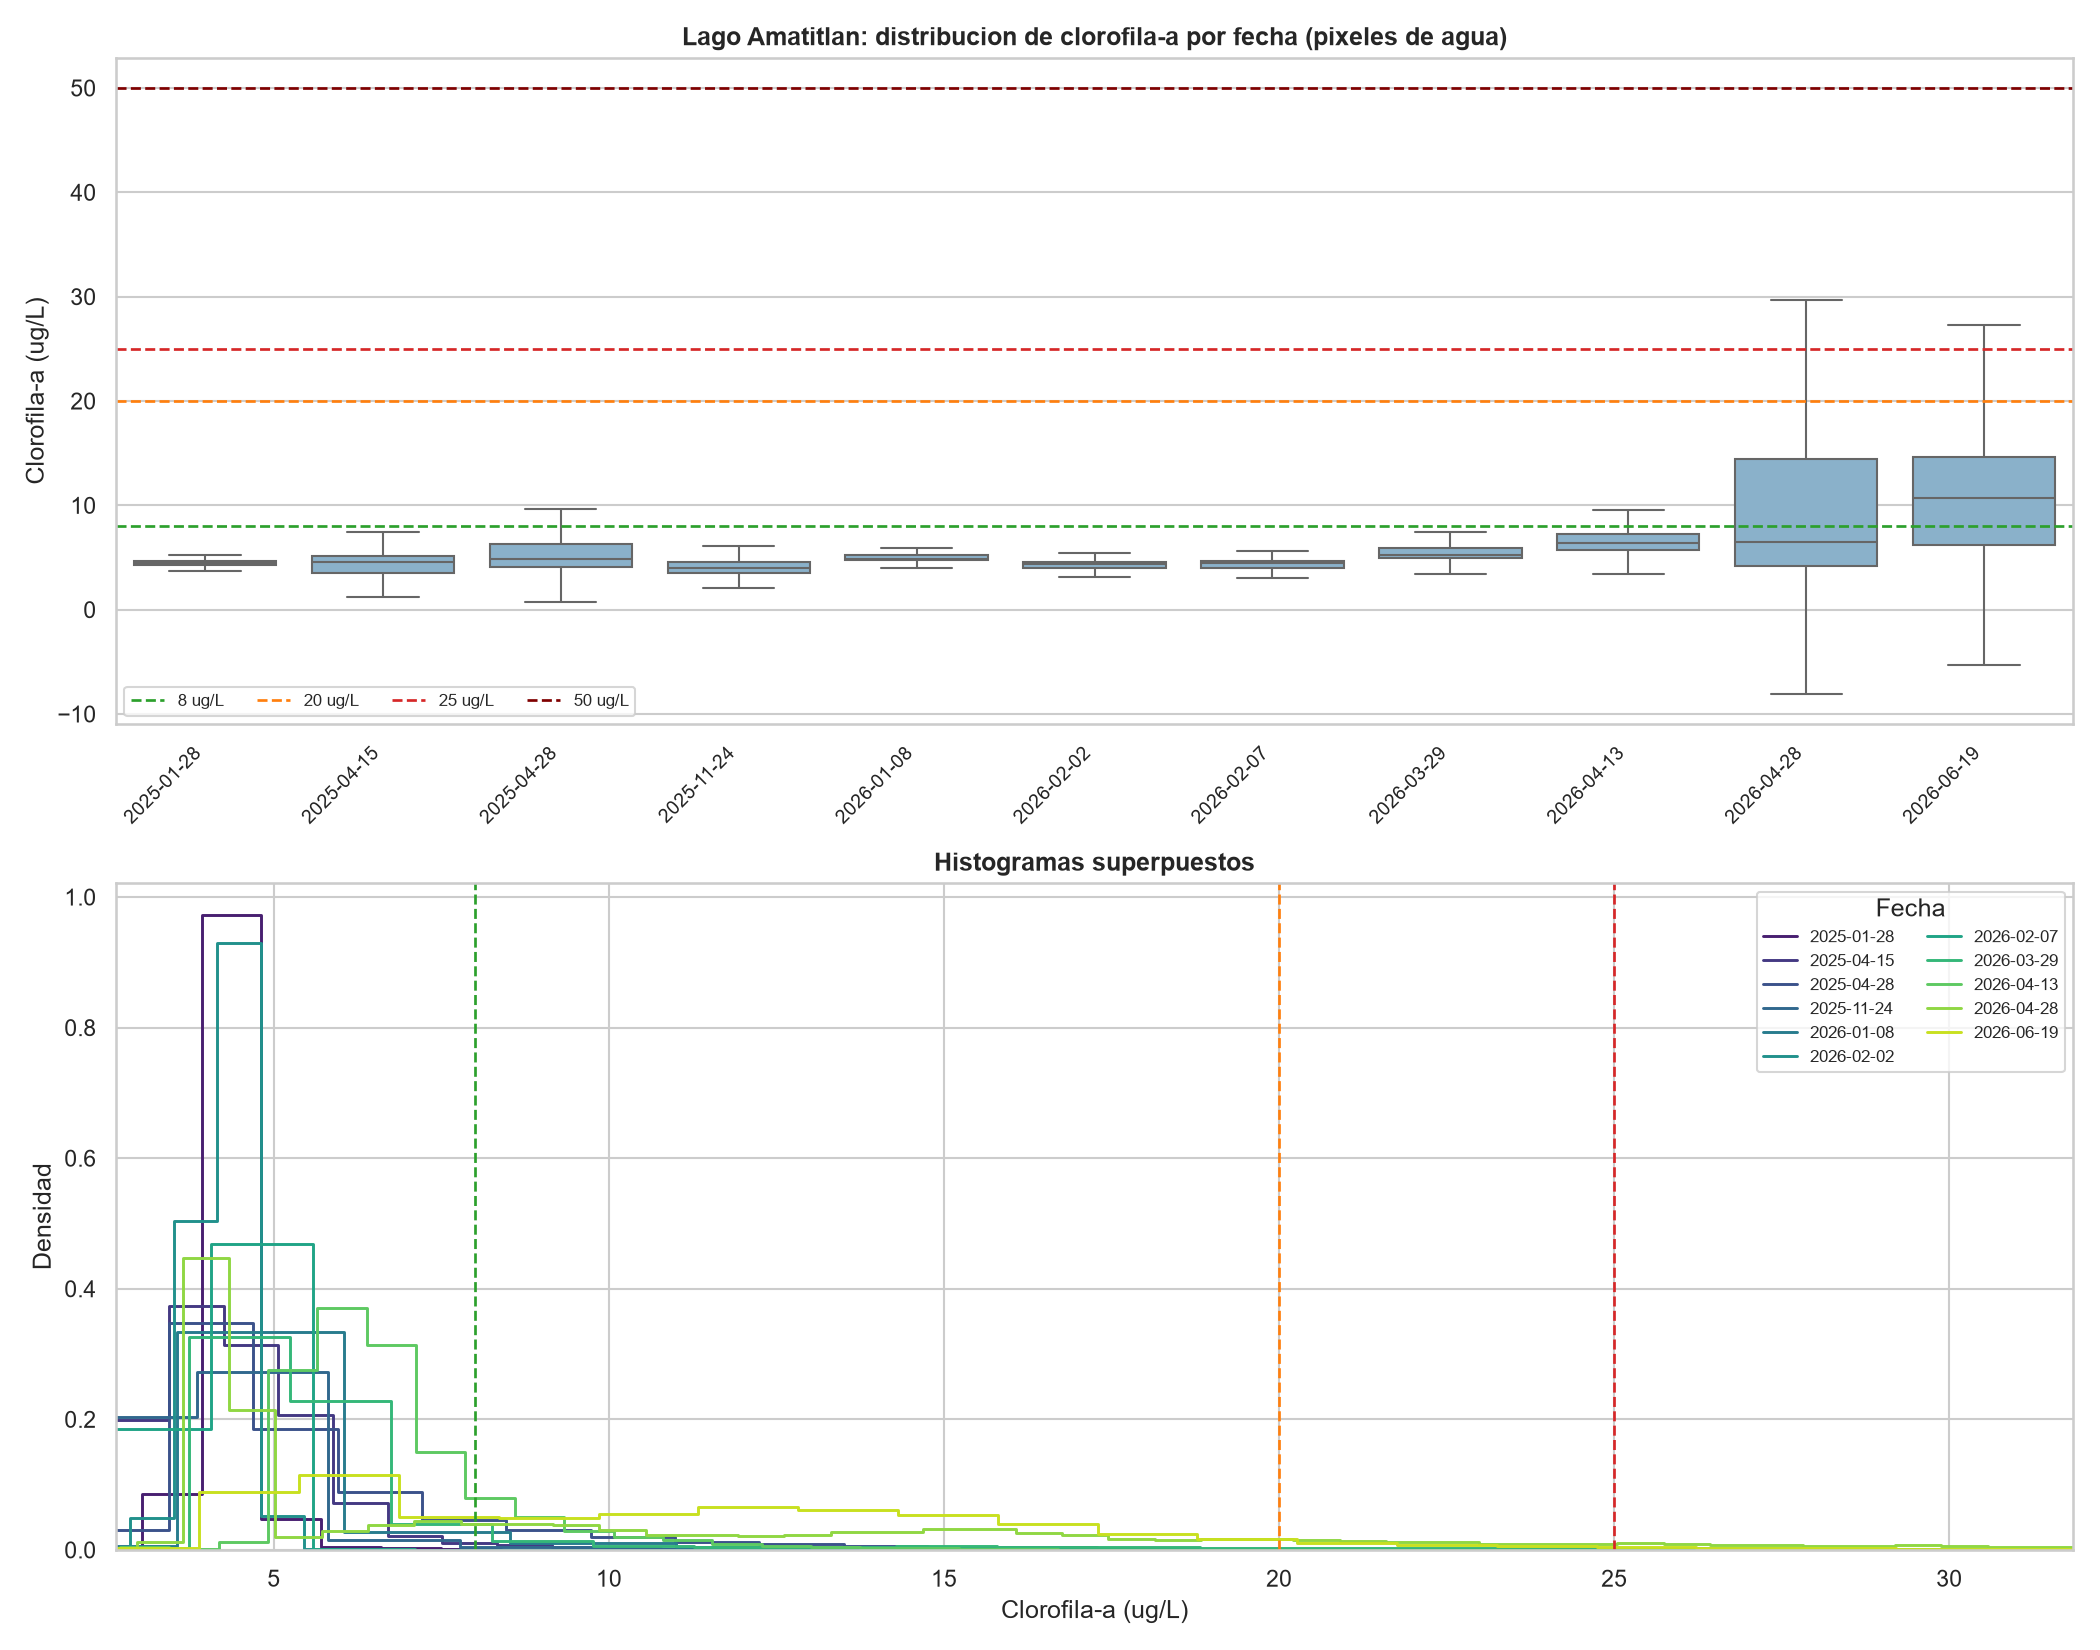

#### Lago Atitlan: distribuciones por fecha

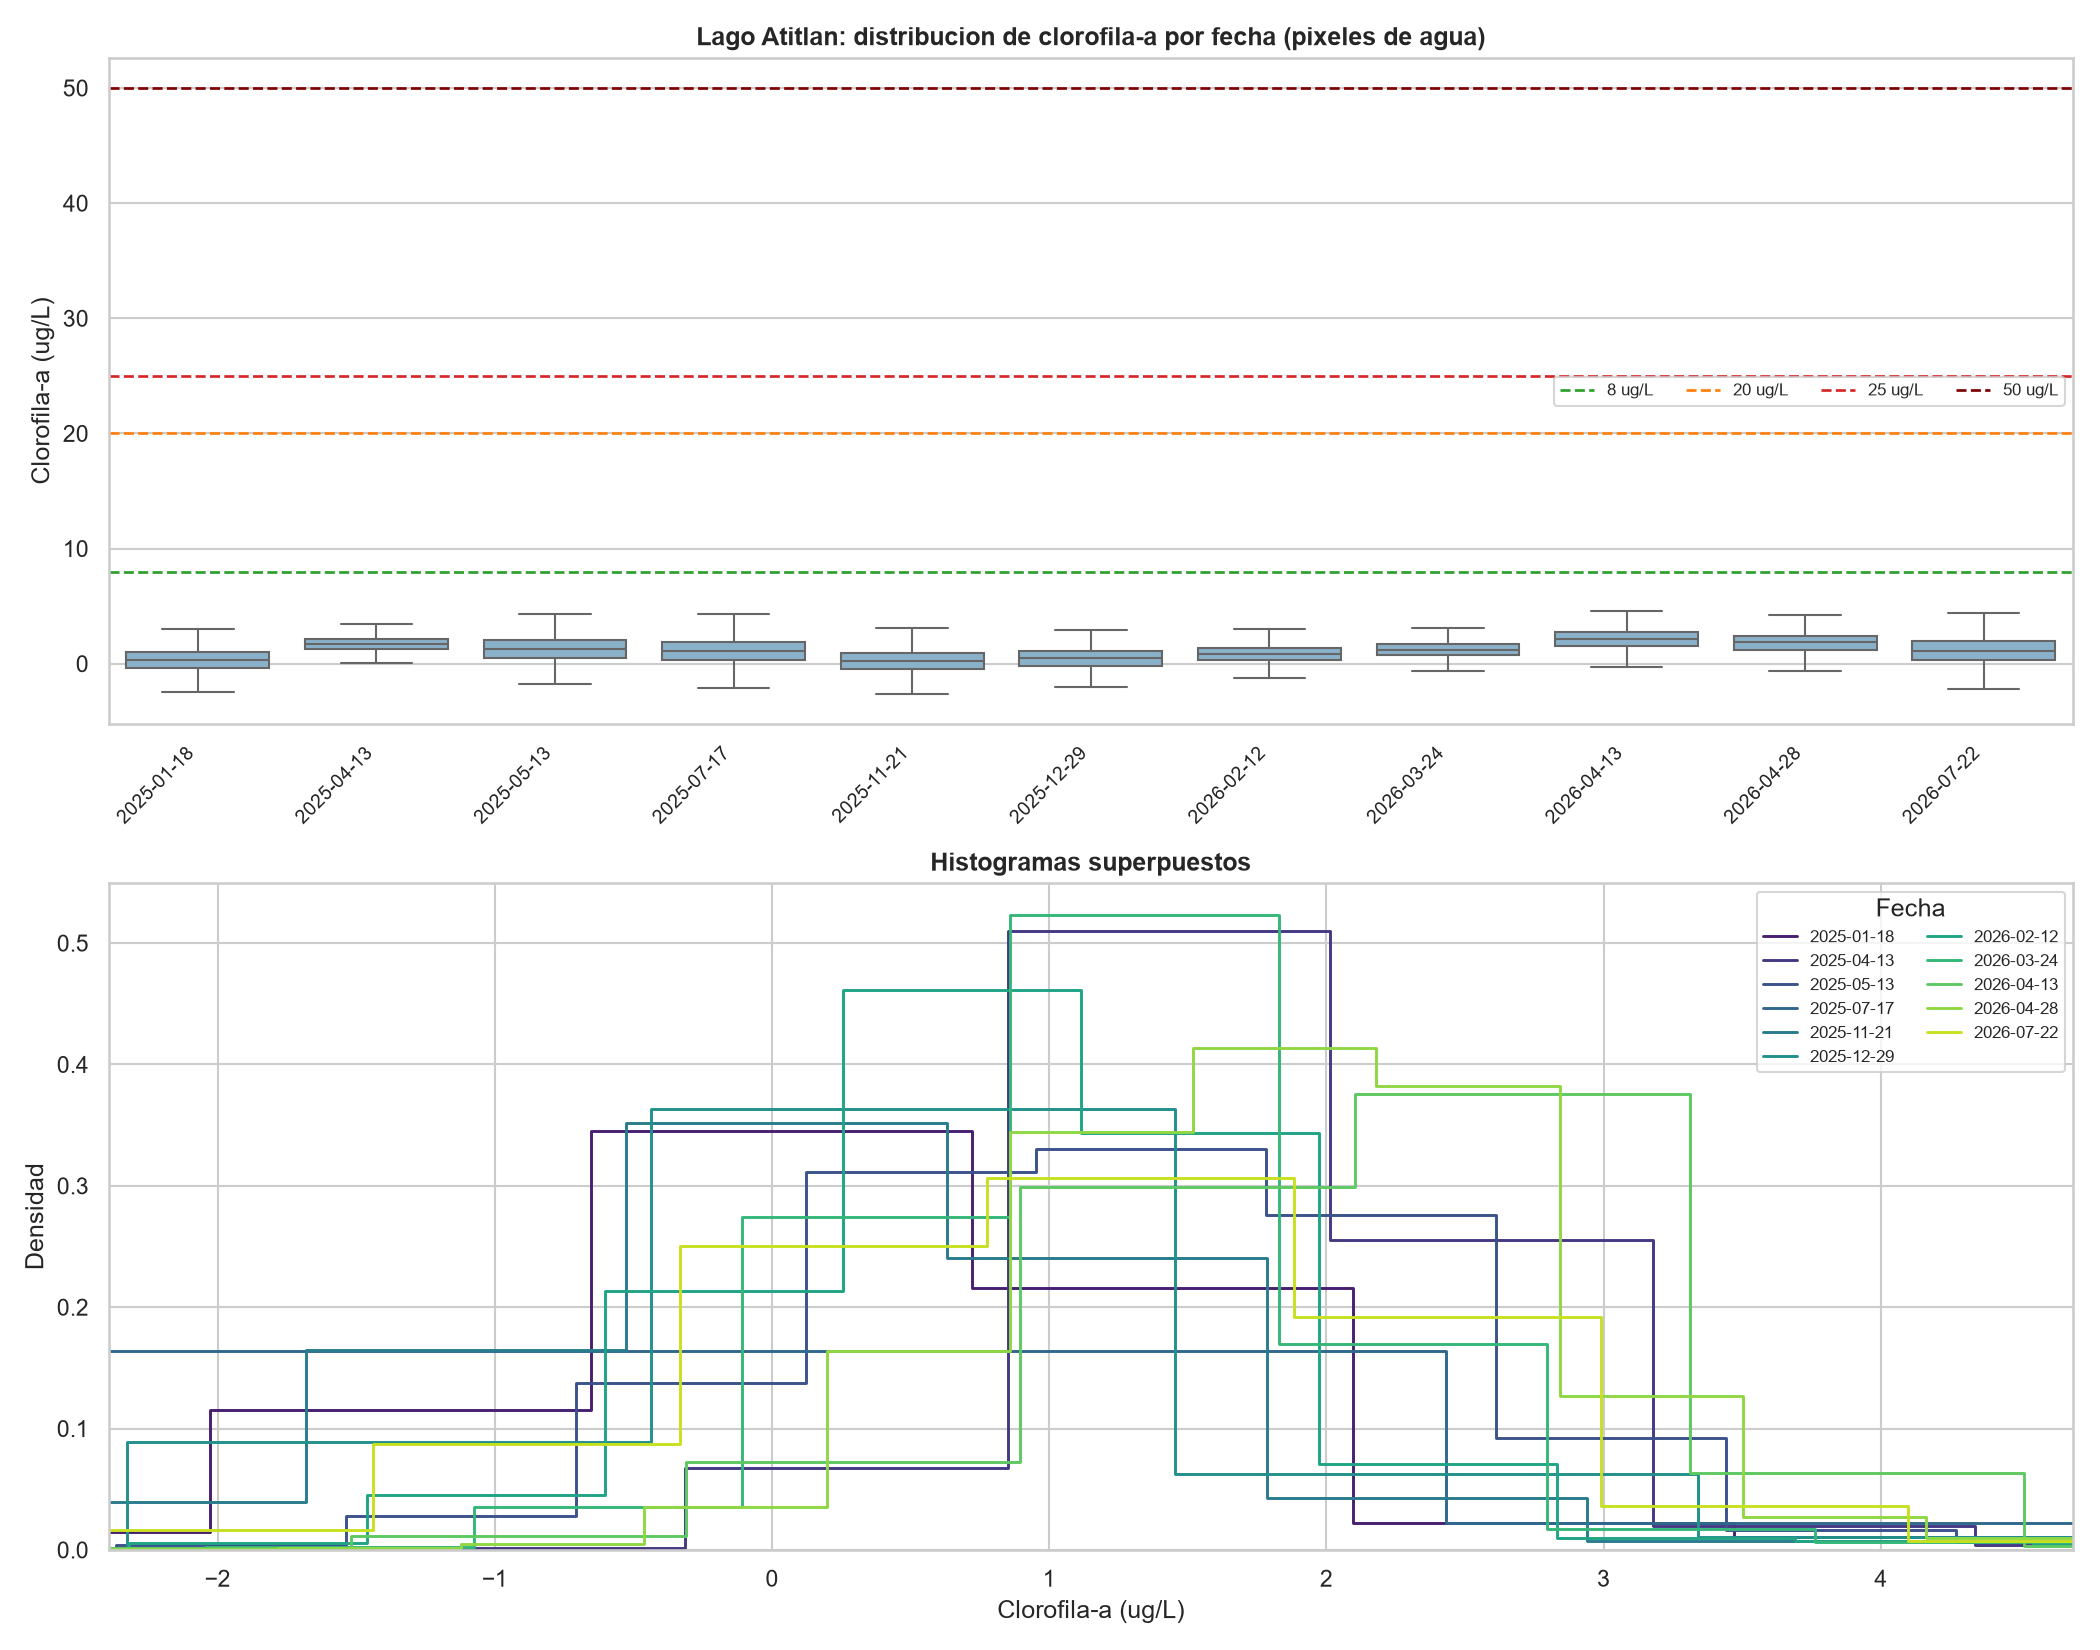

In [13]:
for lago in sorted(OFFICIAL_DATES):
    display(Markdown(f"#### Lago {lago}: distribuciones por fecha"))
    display(Image(filename=str(FIG / f"actividad8_distribuciones_{lago}.png")))

#### Lago Amatitlan: persistencia espacial

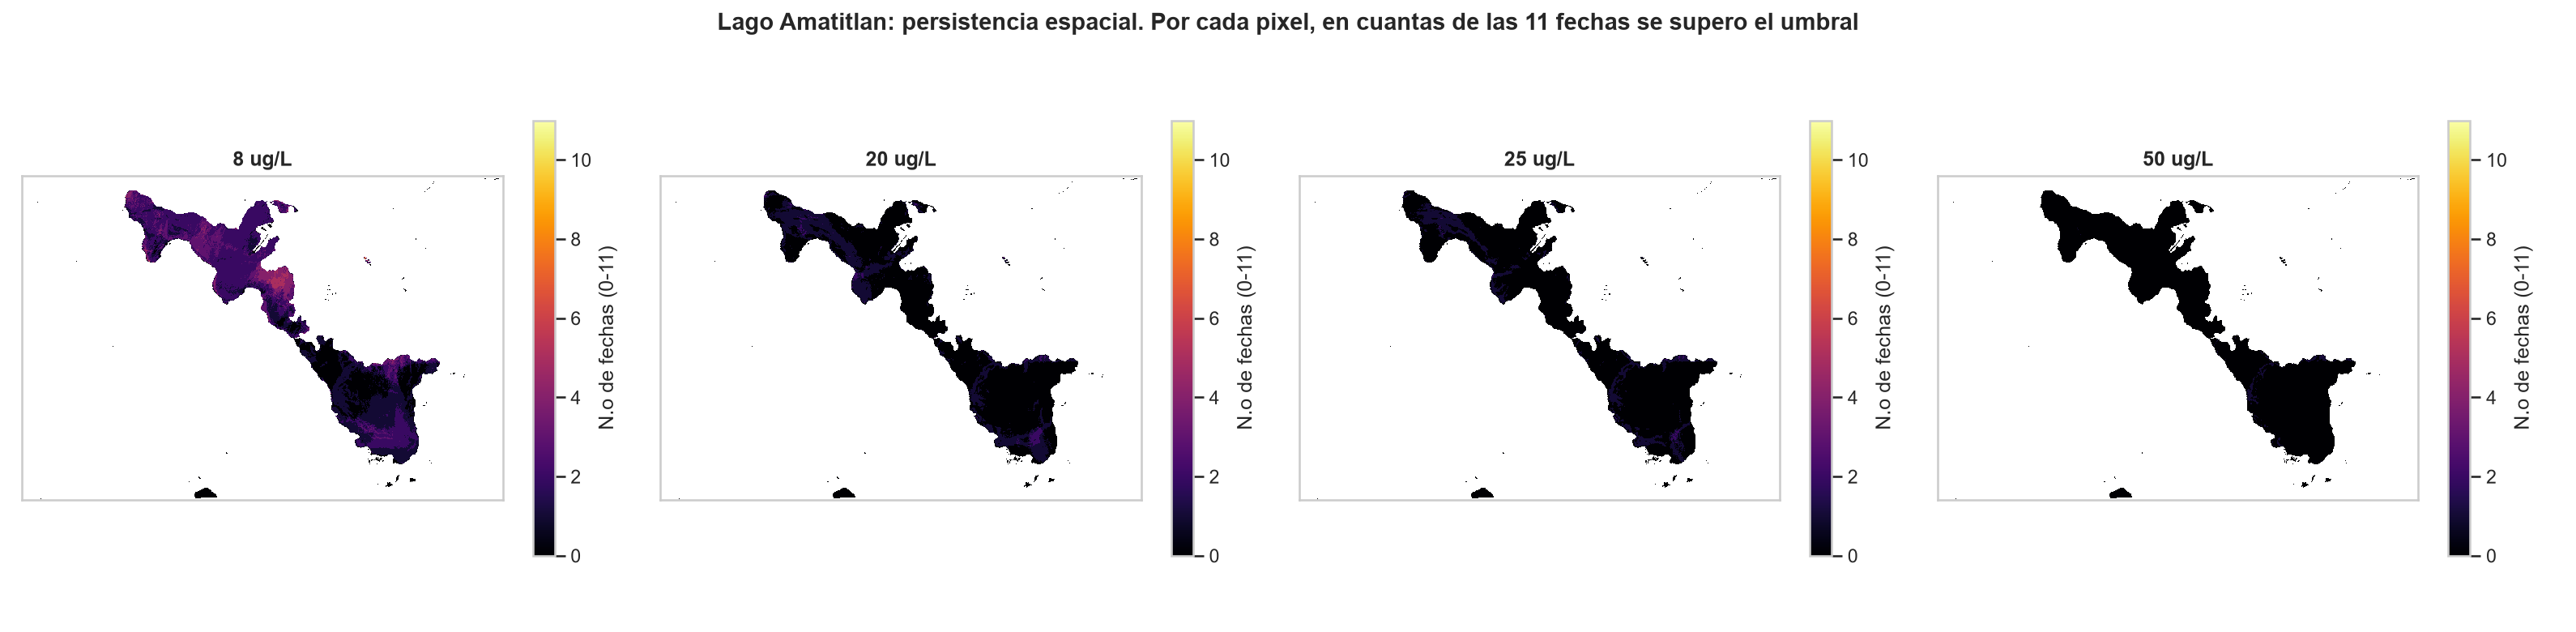

,lago,umbral_ug_L,n_fechas_superadas,n_pixeles,area_ha
9,Amatitlan,8.0,9,1,0.04
8,Amatitlan,8.0,8,1,0.04
7,Amatitlan,8.0,7,1,0.04
6,Amatitlan,8.0,6,7,0.28
5,Amatitlan,8.0,5,408,16.32
4,Amatitlan,8.0,4,1321,52.84
3,Amatitlan,8.0,3,4088,163.52
2,Amatitlan,8.0,2,14181,567.24


#### Lago Atitlan: persistencia espacial

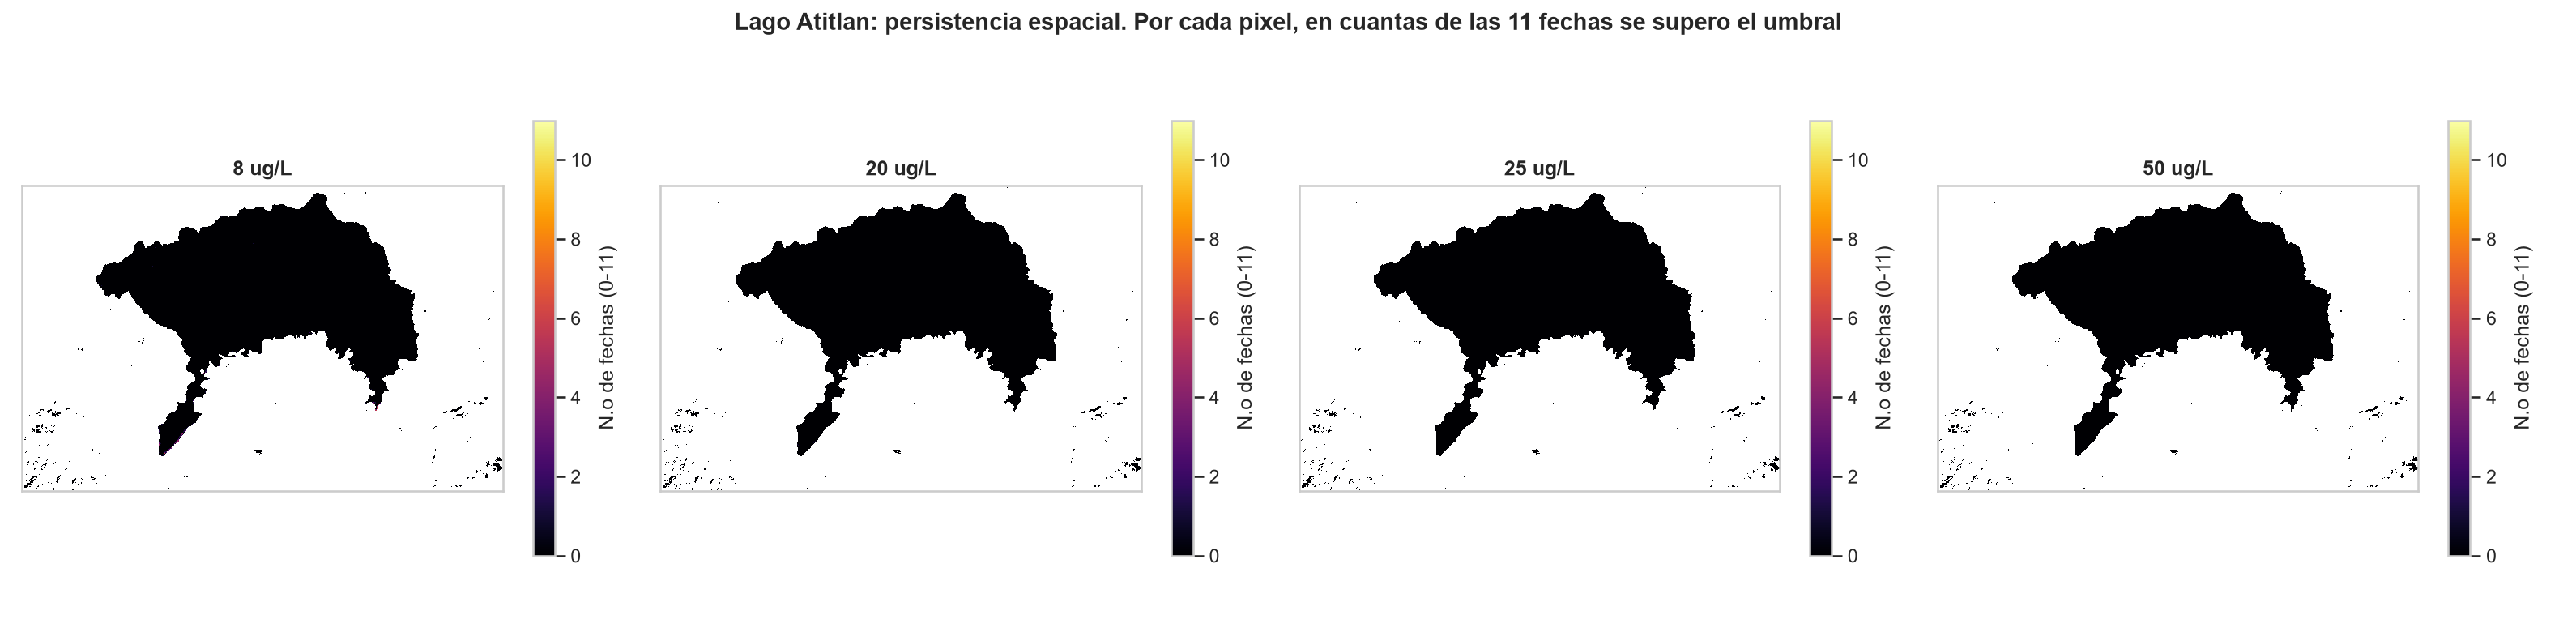

,lago,umbral_ug_L,n_fechas_superadas,n_pixeles,area_ha
8,Atitlan,8.0,8,1,0.04
7,Atitlan,8.0,7,5,0.20
6,Atitlan,8.0,6,18,0.72
5,Atitlan,8.0,5,44,1.76
4,Atitlan,8.0,4,83,3.32
3,Atitlan,8.0,3,117,4.68
2,Atitlan,8.0,2,208,8.32
1,Atitlan,8.0,1,680,27.20


In [14]:
for lago in sorted(OFFICIAL_DATES):
    display(Markdown(f"#### Lago {lago}: persistencia espacial"))
    display(Image(filename=str(MAP / f"actividad8_persistencia_{lago}.png")))
    p = pd.read_csv(TAB / f"persistencia_espacial_{lago}.csv")
    display(p[p["umbral_ug_L"] == 8.0].sort_values("n_fechas_superadas", ascending=False).head(8))

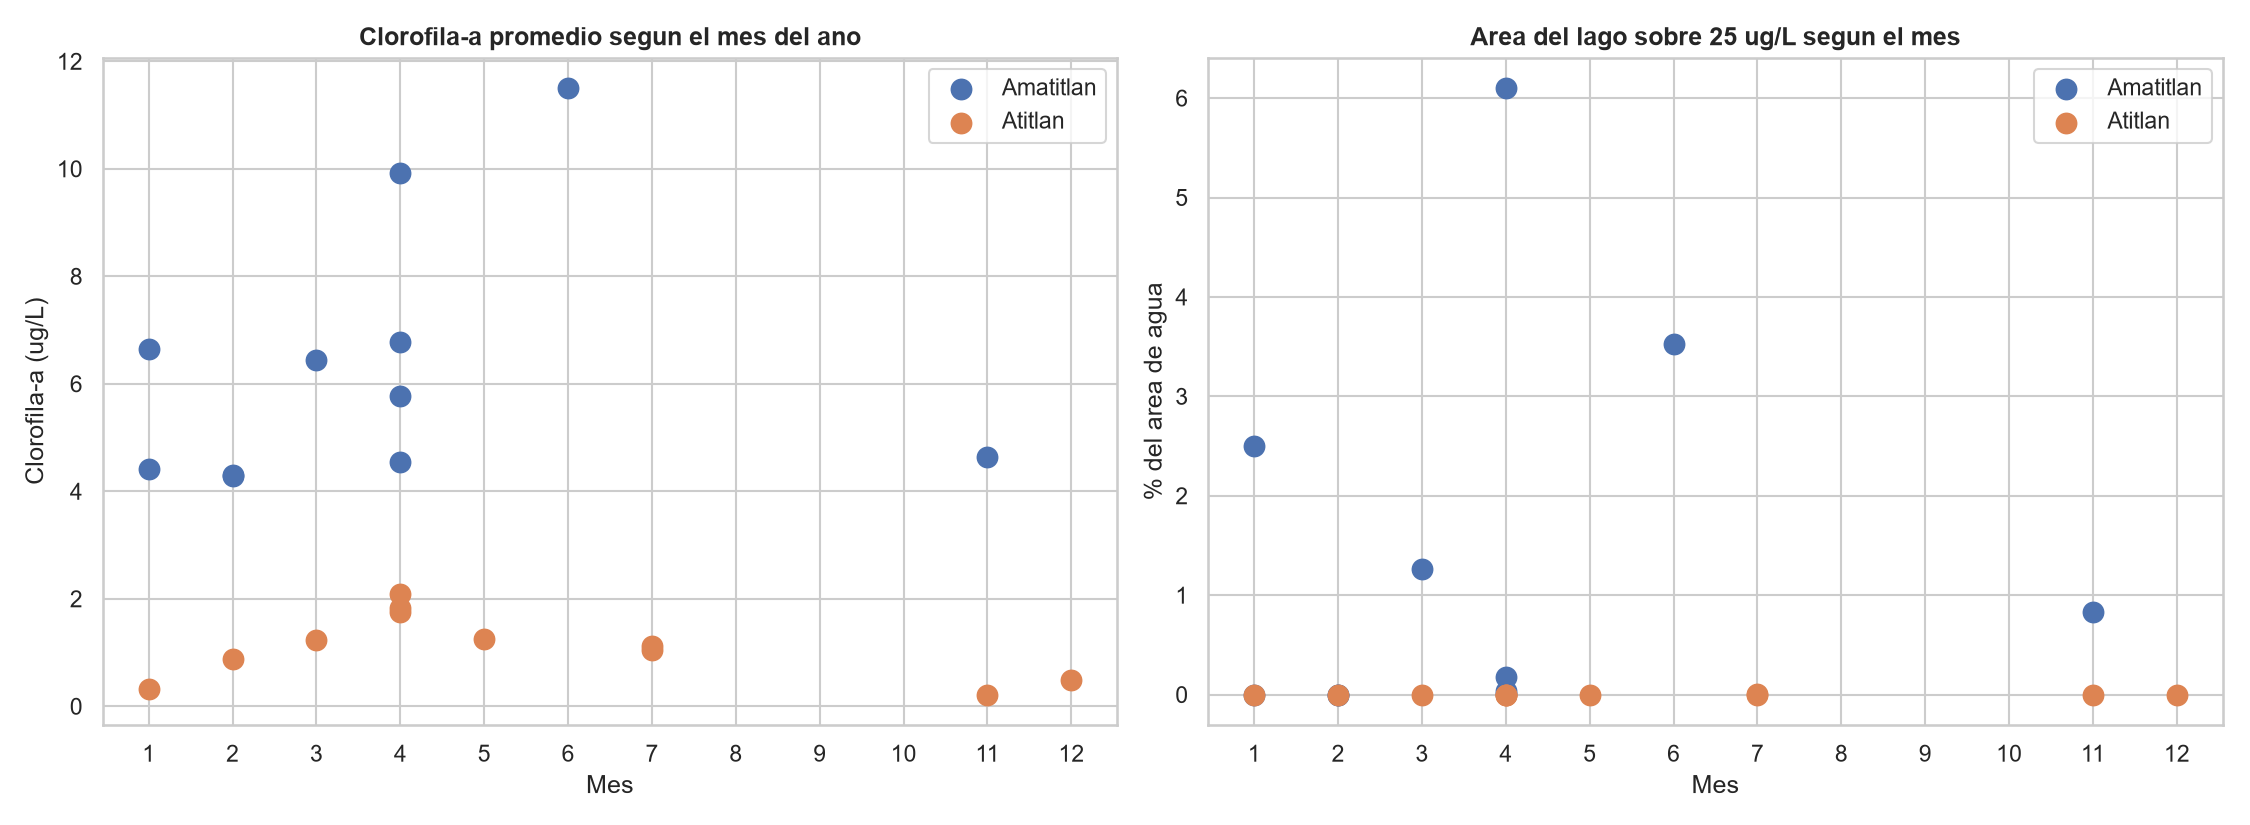

In [15]:
display(Image(filename=str(FIG / "actividad8_patron_estacional.png")))

## Análisis de umbrales ambientales

Los cuatro umbrales evaluados **no significan lo mismo**:

| Umbral | Significado ambiental |
|---|---|
| **8 µg/L** | Frontera mesotrófico → eutrófico (OECD 1982): inicio de la condición eutrófica |
| **20 µg/L** | Usado en la primera versión de la Parte 1. Cae dentro de la banda eutrófica (8–25) y del rango de Alerta 1 de la OMS (12–24), pero **no es una frontera publicada** |
| **25 µg/L** | Frontera eutrófico → hipertrófico (OECD 1982); coincide con el techo de la Alerta 1 de la OMS (24 µg/L) |
| **50 µg/L** | Escenario severo. **No aparece** como valor de clorofila-a en OECD 1982 ni en las guías de la OMS 2021 |


In [16]:
display(Markdown("**Global**"))
display(pd.read_csv(TAB / "threshold_analysis_global.csv").drop(columns=["significado_ambiental"]).round(4))
display(Markdown("**Por lago**"))
display(pd.read_csv(TAB / "threshold_analysis_by_lake.csv").round(4))
display(Markdown("**Viabilidad para un modelo binario (Parte 2)**"))
via = pd.read_csv(TAB / "threshold_model_viability.csv")
display(via[["umbral_ug_L", "pct_positivo_global", "positivos_por_lago",
             "viable_entrenar_por_lago", "viable_evaluar_entre_lagos", "observacion"]])

**Global**

,umbral_ug_L,pixeles_positivos,pixeles_agua,pct_positivo,area_afectada_ha,fechas_con_positivos,fechas_totales
0,8.0,60146,3756512,1.6011,2405.84,22,22
1,20.0,9832,3756512,0.2617,393.28,15,22
2,25.0,5195,3756512,0.1383,207.80,14,22
3,50.0,608,3756512,0.0162,24.32,5,22


**Por lago**

,lago,umbral_ug_L,pixeles_positivos,pixeles_agua,pct_positivo,area_afectada_ha,fechas_con_positivos,fechas_totales,fechas_con_ambas_clases
0,Amatitlan,8.0,57996,399647,14.5118,2319.84,11,11,11
1,Atitlan,8.0,2150,3356865,0.0640,86.00,11,11,11
2,Amatitlan,20.0,9768,399647,2.4442,390.72,9,11,9
3,Atitlan,20.0,64,3356865,0.0019,2.56,6,11,6
4,Amatitlan,25.0,5181,399647,1.2964,207.24,8,11,8
5,Atitlan,25.0,14,3356865,0.0004,0.56,6,11,6
6,Amatitlan,50.0,604,399647,0.1511,24.16,4,11,4
7,Atitlan,50.0,4,3356865,0.0001,0.16,1,11,1


**Viabilidad para un modelo binario (Parte 2)**

,umbral_ug_L,pct_positivo_global,positivos_por_lago,viable_entrenar_por_lago,viable_evaluar_entre_lagos,observacion
0,8.0,1.601113,Amatitlan=57996;Atitlan=2150,False,False,Entrenable solo en Amatitlan. Atitlan solo 215...
1,20.0,0.261732,Amatitlan=9768;Atitlan=64,False,False,Entrenable solo en Amatitlan. Atitlan solo 64 ...
2,25.0,0.138293,Amatitlan=5181;Atitlan=14,False,False,Entrenable solo en Amatitlan. Atitlan solo 14 ...
3,50.0,0.016185,Amatitlan=604;Atitlan=4,False,False,Todos los lagos quedan por debajo del minimo p...


### Recomendación

Se recomienda **25 µg/L** como umbral principal **por su significado ambiental**: es la
frontera eutrófico–hipertrófico de OECD (1982) y coincide con el techo de la Alerta 1 de
la OMS. La elección **no se hizo por balance de clases**.

Discutida aparte, su **viabilidad estadística es limitada**: con datos reales la clase
alta es muy minoritaria y Atitlán aporta pocos píxeles positivos. Para la Parte 2 se
recomienda **8 µg/L como análisis de sensibilidad**, por ser el único umbral en que ambos
lagos tienen una cantidad apreciable de positivos.


## Conclusiones de la Parte 1

1. Los 22 rásteres Sentinel-2 L1C reales permiten estimar clorofila-a con el algoritmo de
   CyanoLakes, **verificado píxel a píxel** contra el evalscript oficial.
2. **Amatitlán y Atitlán están en estados tróficos muy distintos**: Amatitlán muestra
   valores propios de un sistema eutrófico y Atitlán de uno oligotrófico–mesotrófico.
3. Existe un **patrón estacional** con máximos entre abril y junio y mínimos en
   noviembre–diciembre, en ambos lagos.
4. Las floraciones son **espacialmente selectivas y persistentes** en zonas someras.
5. La correlación NDCI–clorofila **no es un hallazgo**: es circular por construcción.
6. Todos los valores son **estimaciones satelitales sin validación in situ**, con un
   algoritmo de MAPE ≈ 42 % calibrado para otra especie y sobre datos simulados.

---

## Apéndice — demostración sintética (OBSOLETA)

Los archivos `outputs/actividad_4_*_demo.*`, `outputs/act5_*`, `outputs/act6_*`,
`outputs/act8_*` y `outputs/evidencia_indices_mapa_sintetico.png` provienen de la versión
sintética anterior. **Se conservan solo como registro histórico del desarrollo y no deben
citarse como resultados ecológicos.** Los resultados válidos son los de
`outputs/parte1_real/`.

La función `synthetic_bands()` **ya no se usa** en este cuaderno, ni siquiera como
*fallback*: si falta un ráster real, el pipeline se detiene con un error explícito.
